### PTT WomenTalk「難過」貼文：Embedding-Word2Vec & BERT 

這份 notebook 以課堂第三次讀書會為目標，延續前兩次讀書會的分析基礎，前兩次分析是偏用統計式文字探勘第三次讀書會則會使用語意式文字探勘分析：

-**Part 1 第二次讀書會調整**：調整斷詞和停用字，比較調整前後
-**Part 2 Word2Ve**：用 Word2Vec 找出「朋友／家人」附近的語意網絡
-**Part 3 BERT**：用 BERT 分析貼文語意相似度或情緒脈絡



研究問題：在 PTT WomenTalk「難過」貼文中，「朋友」與「家人」是造成難過的主要來源，還是只是貼文中常出現的關係角色？



資料來源：PTT WomenTalk 板，以「難過」為關鍵字抓取，共 7,571 篇文章，時間跨度 2021–2025 年。

## 0. 環境、套件與執行提醒

建議在課堂的 `textmining` 環境中執行本 notebook：

```bash
conda activate textmining
pip install jieba scikit-learn networkx gensim pyLDAvis
```

補充說明：
- 本 notebook 的前處理（Step 1）只需執行一次，後續三個 Part 共用同一份斷詞結果與 TF-IDF 矩陣。
- 所有圖表以 notebook cell output 為主，不另外儲存圖片檔。
- 若某些套件缺少，相關段落會自動略過，不讓 notebook 中斷。

# *資料前處理*



---
## 前處理1 ：讀取、清理、斷詞

這一段是所有後續分析的基礎，目的是把原始 CSV 轉換成可供分析的結構化資料。

本段會完成：
- 讀取 CSV，檢查資料大小、欄位與缺值。
- 抽取標題標籤（`[難過]`、`[閒聊]` 等）。
- 清理文字（去網址、簽名檔、非中文字元）。
- jieba 斷詞（搭配自訂詞典與停用字）。


In [274]:
# 1-1 套件匯入

import re, platform, importlib
import pandas as pd
import numpy as np
import jieba
import jieba.posseg as pseg
from collections import Counter
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import matplotlib

# 中文字型設定（依系統自動選擇）
if platform.system() == "Darwin":
    matplotlib.rcParams["font.family"] = ["Arial Unicode MS"]
elif platform.system() == "Windows":
    matplotlib.rcParams["font.family"] = ["Microsoft JhengHei"]
else:
    matplotlib.rcParams["font.family"] = ["Noto Sans CJK TC"]

matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# 檢查選用套件
optional = ["networkx", "seaborn", "gensim", "pyLDAvis"]
for pkg in optional:
    status = " " if importlib.util.find_spec(pkg) else "未安裝"
    print(f"  {pkg}: {status}")

print("\n必要套件載入完成")

  networkx:  
  seaborn:  
  gensim:  
  pyLDAvis:  

必要套件載入完成


In [171]:
# 1-2 設定工作目錄與輸出資料夾

from pathlib import Path

base_dir = Path.cwd()

data_path = base_dir / "Rawdata.csv"
results_dir = base_dir / "results"

results_dir.mkdir(parents=True, exist_ok=True)

print(f"目前工作目錄：{base_dir}")
print(f"資料檔案位置：{data_path}")
print(f"分析結果輸出：{results_dir}")

目前工作目錄：C:\Users\uh52j\Untitled Folder
資料檔案位置：C:\Users\uh52j\Untitled Folder\Rawdata.csv
分析結果輸出：C:\Users\uh52j\Untitled Folder\results


## 前處理2-讀取資料與基本檢查

這一段的目的，是先回答最基本的研究設計問題：資料從哪裡來、期間多長、規模多大。

本段會完成：
- 讀取 CSV。
- 檢查資料大小、欄位、缺值、重複網址。
- 將 `artDate` 轉為 datetime，建立 `year`、`month_of_year` 等時間欄位。
- 說明資料期間與資料筆數。

In [276]:
# 1-3 讀取原始資料
from pathlib import Path

data_path = Path(r"C:\Users\uh52j\OneDrive\桌面\社群讀書會\Rawdata.csv")

if not data_path.exists():
    raise FileNotFoundError(f"找不到資料檔：{data_path}")

df_raw = pd.read_csv(data_path, encoding="utf-8-sig", low_memory=False)
print(f"成功讀取資料")
print(f"資料 shape：{df_raw.shape}")
print(f"欄位名稱：{df_raw.columns.tolist()}")
df_raw.head(3)

成功讀取資料
資料 shape：(7571, 11)
欄位名稱：['system_id', 'artUrl', 'artTitle', 'artDate', 'artPoster', 'artCatagory', 'artContent', 'artComment', 'e_ip', 'insertedDate', 'dataSource']


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/WomenTalk/M.1609431742....,[難過]2020年12月步數不足,2021-01-01 00:22:20,johanzhou,WomenTalk,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""rukawa514"", ...",42.74.30.7,2021-01-01 00:56:55,ptt
1,2,https://www.ptt.cc/bbs/WomenTalk/M.1609453123....,[難過]陽台又淹水了,2021-01-01 06:18:41,ffooxx,WomenTalk,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""molopo"", ""cm...",49.216.68.245,2021-01-02 00:46:24,ptt
2,3,https://www.ptt.cc/bbs/WomenTalk/M.1609473812....,[閒聊]關於朋友這件事：（,2021-01-01 12:03:30,winnie5286,WomenTalk,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""g7a7n7"", ""cm...",27.242.222.34,2021-01-02 00:46:24,ptt


In [278]:
# 1-4 檢查缺值

missing_table = df_raw.isna().sum().reset_index()
missing_table.columns = ["column", "missing_count"]
missing_table["missing_ratio"] = (missing_table["missing_count"] / len(df_raw)).round(4)
print("表 1-4 缺值統計")
display(missing_table)

表 1-4 缺值統計


,column,missing_count,missing_ratio
0,system_id,0,0.0000
1,artUrl,0,0.0000
2,artTitle,0,0.0000
3,artDate,0,0.0000
4,artPoster,0,0.0000
5,artCatagory,0,0.0000
6,artContent,7,0.0009
7,artComment,0,0.0000
8,e_ip,48,0.0063
9,insertedDate,0,0.0000


In [280]:
# 1-5 檢查重複網址

duplicate_url_count = df_raw["artUrl"].duplicated().sum()
print(f"artUrl 重複筆數：{duplicate_url_count}")

# 建立主分析用的 df（去除 artContent 缺值的列）
df = df_raw.dropna(subset=["artContent"]).copy().reset_index(drop=True)
print(f"排除內文缺值後：{len(df)} 篇")

artUrl 重複筆數：0
排除內文缺值後：7564 篇


In [282]:
# 1-6 建立日期欄位與月份統計

df["artDate_dt"] = pd.to_datetime(df["artDate"], errors="coerce")
df["year"] = df["artDate_dt"].dt.year
df["month_of_year"] = df["artDate_dt"].dt.month

month_order = list(range(1, 13))
month_label_map = {m: f"{m}月" for m in month_order}

date_min = df["artDate_dt"].min()
date_max = df["artDate_dt"].max()
print(f"資料期間：{date_min.date()} ~ {date_max.date()}")
print(f"共跨 {df['year'].nunique()} 個年份：{sorted(df['year'].dropna().unique().astype(int))}")

monthly_counts = df.groupby("month_of_year").size().reindex(month_order, fill_value=0)
print(f"\n各月份文章數：")
for m, c in monthly_counts.items():
    print(f"  {m:2d}月：{c} 篇")

資料期間：2021-01-01 ~ 2025-12-20
共跨 5 個年份：[2021, 2022, 2023, 2024, 2025]

各月份文章數：
   1月：761 篇
   2月：627 篇
   3月：597 篇
   4月：583 篇
   5月：652 篇
   6月：588 篇
   7月：600 篇
   8月：542 篇
   9月：638 篇
  10月：654 篇
  11月：687 篇
  12月：635 篇


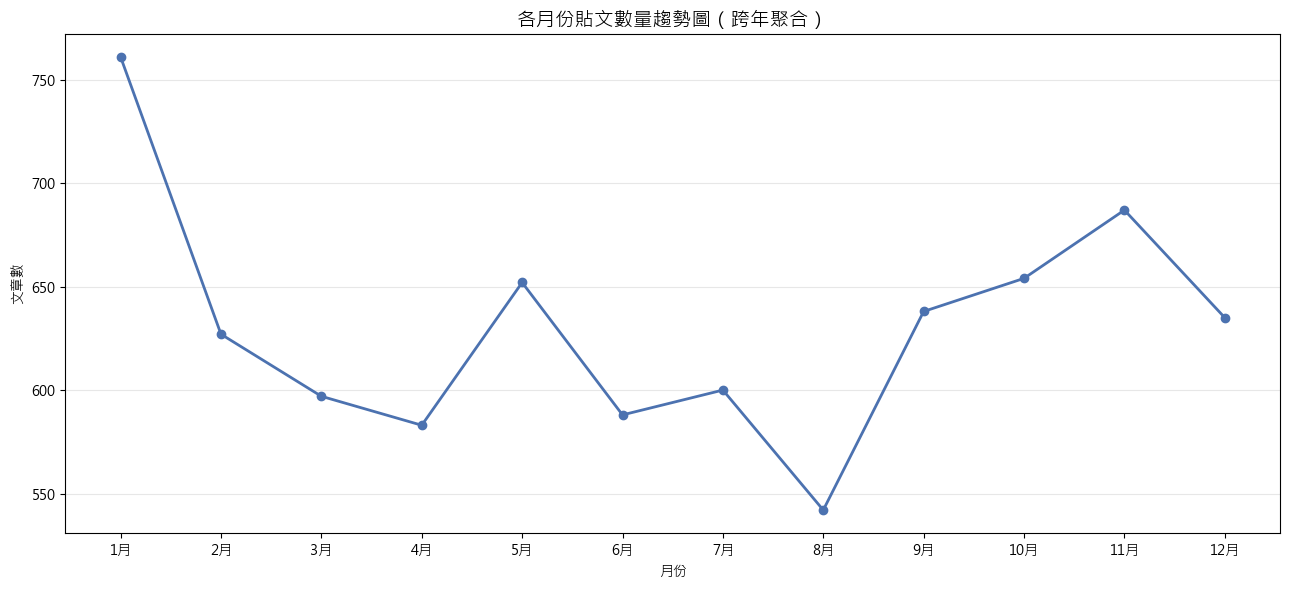

In [284]:
# 1-7 繪製各月份貼文數量趨勢圖

plt.figure(figsize=(13, 6))
plt.plot(monthly_counts.index, monthly_counts.values, marker="o", color="#4C72B0", linewidth=2)
plt.title("各月份貼文數量趨勢圖（跨年聚合）", fontsize=14)
plt.xlabel("月份")
plt.ylabel("文章數")
plt.xticks(month_order, [month_label_map[m] for m in month_order])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 前處理 3-文字清理與分析欄位建立

這一段對應課堂中的**前處理**，重點是把原始文字轉換成可供斷詞的乾淨文字。

主要處理：
- 抽取標題標籤（`[難過]`、`[閒聊]` 等），判斷是否為回文 `Re:` 或轉文 `Fw:`。
- 清理內文：移除網址、email、簽名檔、發信站資訊、非中文字元。
- 建立 `clean_content`（清理後內文）與 `analysis_text`（標題 + 內文合併）。
- 計算文章長度。

這樣做的好處是讓後面的斷詞不會被 URL、英文代碼等雜訊帶偏。

In [287]:
# 2-1 建立文字清理函式與分析欄位

def extract_tag(title):
    """抽取標題最前面的 [標籤]，容許 Re:/Fw: 前綴。"""
    if pd.isna(title):
        return "無標籤"
    title = str(title).strip()
    title = re.sub(r"^\s*(?:Re|Fw):\s*", "", title, flags=re.IGNORECASE)
    m = re.match(r"\[(.+?)\]", title)
    return m.group(1) if m else "無標籤"

def clean_title(title):
    """移除標籤與 Re:/Fw: 後的乾淨標題。"""
    if pd.isna(title):
        return ""
    title = str(title).strip()
    title = re.sub(r"^\s*(?:Re|Fw):\s*", "", title, flags=re.IGNORECASE)
    title = re.sub(r"^\[.+?\]\s*", "", title)
    return title.strip()

def clean_content(text):
    """清理 PTT 文章內文。"""
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[a-zA-Z0-9_]+@[a-zA-Z0-9_.]+", "", text)
    text = re.sub(r"--\n.*", "", text, flags=re.DOTALL)
    text = re.sub(r"※\s*發信站.*", "", text)
    text = re.sub(r"※\s*文章網址.*", "", text)
    text = re.sub(r"[^\u4e00-\u9fff\u3400-\u4dbf，。！？、；：「」（）\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 套用清理
df["tag"] = df["artTitle"].apply(extract_tag)
df["is_reply"] = df["artTitle"].str.contains(r"^\s*Re:", flags=re.IGNORECASE, na=False)
df["is_forward"] = df["artTitle"].str.contains(r"^\s*Fw:", flags=re.IGNORECASE, na=False)
df["clean_title"] = df["artTitle"].apply(clean_title)
df["clean_content"] = df["artContent"].apply(clean_content)
df["analysis_text"] = (df["clean_title"] + " " + df["clean_content"]).str.strip()
df["text_length"] = df["clean_content"].str.len()

print("文字清理完成")
print(f"平均內文長度：{df['text_length'].mean():.0f} 字")
print(f"中位數長度：{df['text_length'].median():.0f} 字")

文字清理完成
平均內文長度：238 字
中位數長度：117 字


In [289]:
# 2-2 顯示清理前後示例

examples = df.loc[
    df["clean_content"].str.len() > 50,
    ["artTitle", "clean_title", "artContent", "clean_content"]
].head(3).copy()
examples["artContent_preview"] = examples["artContent"].str[:150] + "..."
examples["clean_content_preview"] = examples["clean_content"].str[:150] + "..."

print("表 2-2 清理前後示例（前 3 篇）")
display(examples[["artTitle", "clean_title", "artContent_preview", "clean_content_preview"]])

表 2-2 清理前後示例（前 3 篇）


,artTitle,clean_title,artContent_preview,clean_content_preview
0,[難過]2020年12月步數不足,2020年12月步數不足,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,年 月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。 平均一天也不...
1,[難過]陽台又淹水了,陽台又淹水了,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,大家 早安，我芙尼。 大概五點的時候我被一陣電鈴聲吵醒， 門一打開發現是樓下的鄰居， 她問我...
2,[閒聊]關於朋友這件事：（,關於朋友這件事：（,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,不知道是不是年紀的關係 真的感覺身邊都沒有朋友了。 以為是真心的朋友，在我遇到很難過的事情想...


In [291]:
# 2-3 文章長度統計

print("表 2-3 文章長度基本統計（以 clean_content 字元數計算）")
display(df["text_length"].describe().round(1).to_frame("text_length"))

表 2-3 文章長度基本統計（以 clean_content 字元數計算）


,text_length
count,7564.0
mean,237.6
std,453.2
min,0.0
25%,78.0
50%,117.0
75%,231.0
max,21645.0


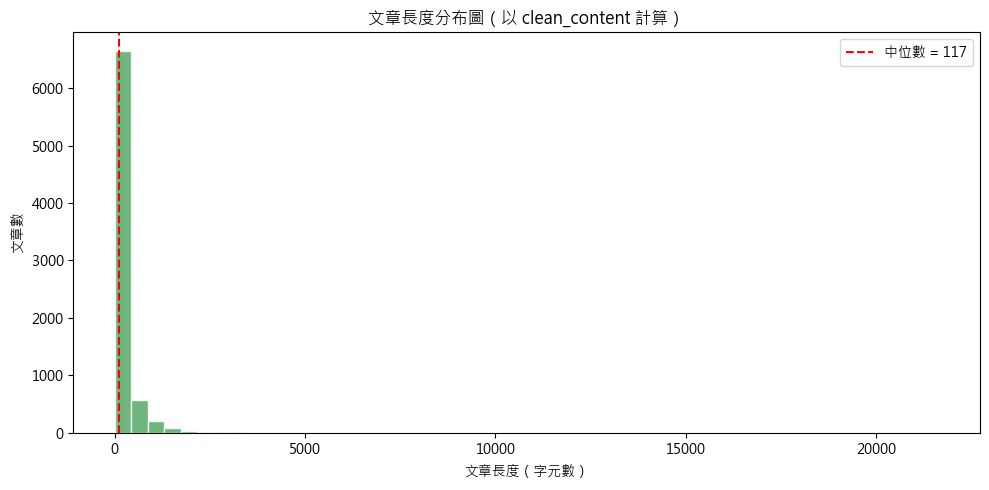

In [293]:
# 2-4 繪製文章長度分布圖

plt.figure(figsize=(10, 5))
plt.hist(df["text_length"], bins=50, color="#55A868", edgecolor="white", alpha=0.85)
plt.axvline(df["text_length"].median(), color="red", linestyle="--",
            label=f"中位數 = {df['text_length'].median():.0f}")
plt.xlabel("文章長度（字元數）")
plt.ylabel("文章數")
plt.title("文章長度分布圖（以 clean_content 計算）")
plt.legend()
plt.tight_layout()
plt.show()

In [295]:
# 2-5 標題標籤分布與回文比例

tag_counts = df["tag"].value_counts().reset_index()
tag_counts.columns = ["tag", "count"]
tag_counts["ratio"] = (tag_counts["count"] / len(df)).round(4)

print("表 2-5 標題標籤分布")
display(tag_counts)

reply_ratio = df["is_reply"].mean()
print(f"\n回文（Re:）比例：{reply_ratio:.2%}（{df['is_reply'].sum()} 篇）")
print(f"轉文（Fw:）比例：{df['is_forward'].mean():.2%}（{df['is_forward'].sum()} 篇）")

表 2-5 標題標籤分布


,tag,count,ratio
0,難過,6218,0.8221
1,閒聊,495,0.0654
2,心情,366,0.0484
3,討論,164,0.0217
4,問題,153,0.0202
5,新聞,123,0.0163
6,無標籤,19,0.0025
7,灑花,14,0.0019
8,活動,4,0.0005
9,問卦,3,0.0004



回文（Re:）比例：21.51%（1627 篇）
轉文（Fw:）比例：0.22%（17 篇）


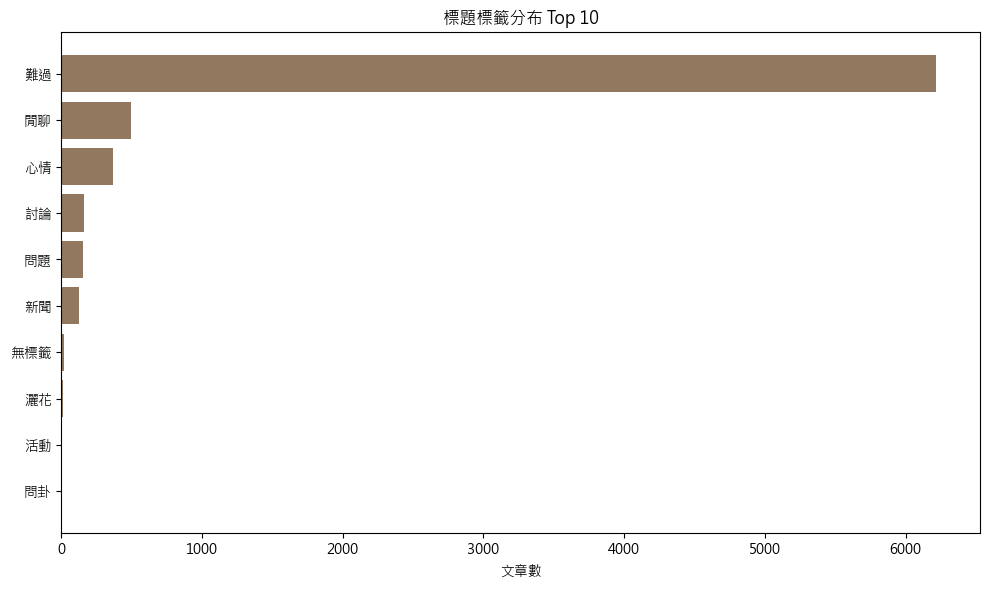

In [297]:
# 2-6 繪製標題標籤分布圖

top_tags = tag_counts.head(10)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_tags)-1, -1, -1), top_tags["count"], color="#937860")
plt.yticks(range(len(top_tags)-1, -1, -1), top_tags["tag"])
plt.xlabel("文章數")
plt.title("標題標籤分布 Top 10")
plt.tight_layout()
plt.show()

## 前處理 4-斷詞、自訂詞典與停用字

這一段是文字探勘的核心前處理。
為了讓 jieba 正確辨識 PTT 與情感領域的用詞，這裡會載入自訂詞典並設定停用字。

處理流程：
1. 載入自訂詞典（感情、職場、家庭、情緒相關用詞）。
2. 設定停用字（功能詞 + PTT 常見雜訊詞 + 「難過」本身）。
3. 對每篇文章執行 jieba 斷詞。
4. 建立 `tokens`（詞列表）與 `tokens_str`（空格分隔字串，給 TF-IDF 用）。

「難過」被列入停用字是因為它是搜尋關鍵字，幾乎每篇都有，留著會淹沒其他有意義的詞。

In [299]:
# 3-1 載入自訂詞典

custom_words = sorted({
    # 感情：分手與失戀
    "分手", "失戀", "前任", "復合", "被甩", "被分手", "失戀中",
    # 感情：曖昧與追求
    "曖昧", "告白", "被拒", "拒絕", "暈船", "單戀", "追求",
    # 感情：伴侶稱謂
    "男友", "女友", "伴侶", "另一半", "老公", "老婆", "先生", "太太",
    "前男友", "前女友",
    # 感情：衝突
    "吵架", "冷戰", "冷暴力", "已讀不回", "沒安全感",
    # 感情：外遇
    "外遇", "劈腿", "出軌", "偷吃", "小三",
    # 職場
    "主管", "上司", "老闆", "職場霸凌", "被罵", "慣老闆",
    "同事", "職場", "離職", "轉職", "面試", "求職",
    # 家庭
    "婆婆", "婆媳", "公婆", "懷孕", "流產", "不孕",
    # 情緒
    "憂鬱", "焦慮", "恐慌", "失眠", "自卑", "崩潰",
    #其他
    "詐騙集團","一段時間","情緒勒索","原生家庭","在網路上","生活品質","代理孕母",
     # Word2Vec新增
    "壓力山大","壓力很大","詐騙集團","詐騙集團","難過","傷心","失望","詐騙集團","難過",
})

for w in custom_words:
    jieba.add_word(w)

print(f"自訂詞典載入完成，共 {len(custom_words)} 個詞")

自訂詞典載入完成，共 70 個詞


In [303]:
# 3-2 設定停用字

stopwords = {
    # 功能詞
    "的", "了", "和", "是", "我", "你", "他", "她", "它", "我們", "你們", "他們",
    "自己", "真的", "就是", "這樣", "那樣", "一個", "一些", "一下", "不是", "因為",
    "所以", "如果", "然後", "但是", "而且", "可以", "還是", "沒有", "有點", "知道",
    "覺得", "可能", "應該", "已經", "非常", "最近", "今天", "昨天", "現在", "時候",
    "東西", "事情", "問題", "什麼", "怎麼", "這個", "那個", "一樣", "一點", "很多",
    "一直", "還有", "只是", "不過", "其實", "那時", "後來", "之前", "之後",
    "雖然", "不會", "大家", "有人", "也是", "這種", "那種", "比較", "感覺", "到底",
    "為什麼", "開始", "希望", "想說", "出來", "告訴", "看到", "過去",
    "啊啊啊","標題","連結","內容","心得","如何","各位","女版","是不是","如題","台灣",
    "早上","這些","那些","結果","這麼","只有",
    # 搜尋關鍵字（幾乎每篇都有，排除以免干擾）
   
    # PTT 雜訊
    "ptt", "womentalk", "發信站", "批踢踢", "文章", "板友",
    # Word2Vec新增停用詞
     "他當", "眼開", "她當", "是當", "而覺", "覺得會", "搭長", "途客" ,"有史","大到","任感",
}

print(f"停用詞設定完成，共 {len(stopwords)} 個")

停用詞設定完成，共 113 個


In [305]:
# 3-3 執行斷詞

def tokenize(text):
    """jieba 斷詞 → 過濾停用字 & 單字。"""
    if not text:
        return []
    words = jieba.cut(text)
    return [w for w in words if w not in stopwords and len(w) >= 2]

print("開始斷詞（約需 1-3 分鐘）...")
df["tokens"] = df["analysis_text"].apply(tokenize)
df["tokens_str"] = df["tokens"].apply(lambda t: " ".join(t))

print(f"斷詞完成")
print(f"平均每篇：{df['tokens'].apply(len).mean():.0f} 個詞")
print(f"\n前 3 篇斷詞預覽：")
for i in range(3):
    print(f"  [{df.iloc[i]['tag']}] {df.iloc[i]['tokens'][:12]}...")

開始斷詞（約需 1-3 分鐘）...
斷詞完成
平均每篇：61 個詞

前 3 篇斷詞預覽：
  [難過] ['2020', '12', '步數', '不足', '月實', '太太', '多事', '沒辦', '法多', '走路', '這幾個', '禮拜']...
  [難過] ['陽台', '淹水', '早安', '芙尼', '大概', '五點', '一陣', '電鈴聲', '吵醒', '一打', '開發現', '鄰居']...
  [閒聊] ['關於', '朋友', '這件', '年紀的關', '身邊', '朋友', '以為', '真心', '朋友', '遇到', '難過', '想訴']...


In [307]:
# 3-4 全語料高頻詞 Top 30（確認斷詞品質）

all_tokens = [w for tokens in df["tokens"] for w in tokens]
freq = Counter(all_tokens)
top30_freq = pd.DataFrame(freq.most_common(30), columns=["word", "count"])

print("表 3-4 全語料高頻詞 Top 30（確認斷詞品質）")
display(top30_freq)

print("\n解讀：若出現過多無意義的功能詞，應回頭補進停用字。")

表 3-4 全語料高頻詞 Top 30（確認斷詞品質）


,word,count
0,難過,2829
1,朋友,1797
2,工作,1795
3,不要,1604
4,發現,1167
5,小孩,1030
6,時間,1016
7,不能,984
8,一起,960
9,喜歡,948



解讀：若出現過多無意義的功能詞，應回頭補進停用字。


## 前處理 5-建立 TF-IDF 矩陣


In [309]:
# 4-1 建立 TF-IDF 矩陣

# 過濾太短的文章
df_analysis = df[df["text_length"] >= 30].copy().reset_index(drop=True)
print(f"分析樣本：{len(df_analysis)} 篇（排除 < 30 字的文章，原始 {len(df)} 篇）")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_analysis["tokens_str"])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF 矩陣建立完成：{tfidf_matrix.shape}")
print(f"   {tfidf_matrix.shape[0]} 篇文章 × {tfidf_matrix.shape[1]} 個特徵詞")

分析樣本：7541 篇（排除 < 30 字的文章，原始 7564 篇）
TF-IDF 矩陣建立完成：(7541, 5000)
   7541 篇文章 × 5000 個特徵詞


In [311]:
# 4-2 輸出前處理完成的資料

output_cols = [
    "artTitle", "tag", "is_reply", "is_forward", "clean_title",
    "artDate", "artContent", "clean_content", "analysis_text",
    "text_length", "year", "month_of_year", "artUrl",
]
df_analysis[output_cols].to_csv(
    results_dir / "cleaned_articles.csv", index=False, encoding="utf-8-sig"
)
print(f"已輸出清理後資料：{results_dir / 'cleaned_articles.csv'}")
print(f"\nStep 1 前處理全部完成。")

已輸出清理後資料：C:\Users\uh52j\Untitled Folder\results\cleaned_articles.csv

Step 1 前處理全部完成。


---
# Part 1 文辭分析(修改斷詞和停用字表較)

這一段使用多種文字統計方法，從不同角度描述語料的詞彙特徵：

| 方法 | 回答什麼問題 |
|------|-------------|
| TF-IDF 關鍵詞 | 哪些詞在區分文章時最重要？ |
| N-gram 統計 | 哪些詞經常連在一起出現？ |
| Bigram 網絡圖 | 詞與詞之間的共現關係長什麼樣？ |
| Pairwise Correlation | 哪些詞傾向一起出現？哪些互斥？ |
| Cosine Similarity | 不同標籤的文章用詞有多相似？ |

## Part 1 -1 TF-IDF 關鍵詞挑選

TF-IDF 的核心想法是：一個詞如果在某篇文章中頻繁出現，但在整體語料中並不常見，那它對該篇文章就特別重要。

這裡會從兩個角度呈現：
1. **全語料** TF-IDF 平均分數最高的詞 — 描述整體語料的關鍵詞輪廓。
2. **各標籤** 的 TF-IDF 關鍵詞 — 比較「難過」、「閒聊」、「心情」、「討論」四類文章的用詞差異。

In [313]:
# P1-1a 全語料 TF-IDF 平均分數 Top 30

mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_tfidf_idx = mean_tfidf.argsort()[::-1][:30]

tfidf_top30 = pd.DataFrame({
    "word": tfidf_feature_names[top_tfidf_idx],
    "mean_tfidf": mean_tfidf[top_tfidf_idx].round(4),
})

print("表 P1-1a 全語料 TF-IDF 平均分數 Top 30")
display(tfidf_top30)

表 P1-1a 全語料 TF-IDF 平均分數 Top 30


,word,mean_tfidf
0,難過,0.0239
1,工作,0.0152
2,朋友,0.0149
3,同事,0.0130
4,發現,0.0118
5,不要,0.0118
6,上班,0.0110
7,喜歡,0.0107
8,小孩,0.0102
9,公司,0.0100


In [315]:
# P1-1b 各標籤的 TF-IDF 關鍵詞 Top 10

print("各標籤 TF-IDF 關鍵詞 Top 10：\n")
for tag_name in ["難過", "閒聊", "心情", "討論"]:
    tag_mask = (df_analysis["tag"] == tag_name).values
    if tag_mask.sum() < 10:
        continue
    tag_mean = np.array(tfidf_matrix[tag_mask].mean(axis=0)).flatten()
    top_idx = tag_mean.argsort()[::-1][:10]
    keywords = ", ".join(tfidf_feature_names[top_idx])
    print(f"  [{tag_name}]（{tag_mask.sum()} 篇）：{keywords}")

各標籤 TF-IDF 關鍵詞 Top 10：

  [難過]（6198 篇）：難過, 工作, 同事, 朋友, 上班, 發現, 不要, 公司, 小孩, 直接
  [閒聊]（495 篇）：難過, 朋友, 喜歡, 好像, 工作, 小孩, 不要, 想到, 人生, 女生
  [心情]（365 篇）：難過, 朋友, 工作, 情緒, 一起, 心情, 不要, 喜歡, 媽媽, 男友
  [討論]（163 篇）：難過, 朋友, 不要, 女生, 喜歡, 一起, 開心, 不能, 好像, 心情


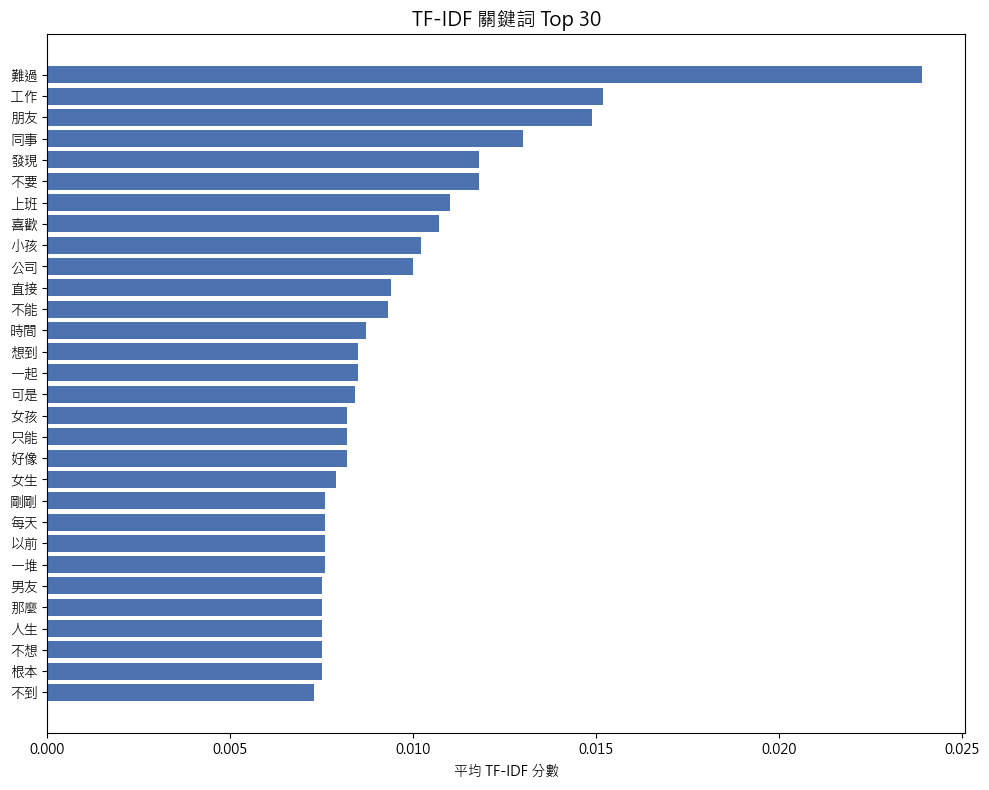

解讀：TF-IDF 分數高的詞代表在區分文章時最具辨識力的詞彙。


In [317]:
# P1-1c 視覺化：TF-IDF Top 30 長條圖

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(tfidf_top30)-1, -1, -1), tfidf_top30["mean_tfidf"], color="#4C72B0")
ax.set_yticks(range(len(tfidf_top30)-1, -1, -1))
ax.set_yticklabels(tfidf_top30["word"])
ax.set_xlabel("平均 TF-IDF 分數")
ax.set_title("TF-IDF 關鍵詞 Top 30", fontsize=14)
plt.tight_layout()
plt.show()

print("解讀：TF-IDF 分數高的詞代表在區分文章時最具辨識力的詞彙。")

## Part 1-2. N-gram 統計

N-gram 統計的目的是找出經常連續出現的詞組合：
- **Bigram（2-gram）**：兩個詞的組合，例如「分手 男友」。
- **Trigram（3-gram）**：三個詞的組合，例如「分手 男友 難過」。

這比單詞頻率多了「詞序」的資訊，能幫助辨識具體事件或固定搭配。

In [319]:
# P1-2a Bigram & Trigram 統計

# Bigram
bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=3000, min_df=3)
bigram_mat = bigram_vec.fit_transform(df_analysis["tokens_str"])
bigram_freq = np.array(bigram_mat.sum(axis=0)).flatten()
bigram_names = bigram_vec.get_feature_names_out()
bigram_top30 = pd.DataFrame({
    "bigram": bigram_names[bigram_freq.argsort()[::-1][:30]],
    "count": sorted(bigram_freq, reverse=True)[:30],
})

# Trigram
trigram_vec = CountVectorizer(ngram_range=(3, 3), max_features=3000, min_df=3)
trigram_mat = trigram_vec.fit_transform(df_analysis["tokens_str"])
trigram_freq = np.array(trigram_mat.sum(axis=0)).flatten()
trigram_names = trigram_vec.get_feature_names_out()
trigram_top20 = pd.DataFrame({
    "trigram": trigram_names[trigram_freq.argsort()[::-1][:20]],
    "count": sorted(trigram_freq, reverse=True)[:20],
})

print("表 P1-2a Bigram Top 30")
display(bigram_top30)
print("\n表 P1-2b Trigram Top 20")
display(trigram_top20)

表 P1-2a Bigram Top 30


,bigram,count
0,無力 難過,58
1,三十 無力,58
2,感到 難過,53
3,大學 畢業,50
4,不想 上班,50
5,普妹 同事,41
6,不能 接受,41
7,經濟 壓力,40
8,心情 不好,37
9,家人 朋友,37



表 P1-2b Trigram Top 20


,trigram,count
0,三十 無力 難過,58
1,不想 上班 不想,26
2,上班 不想 上班,26
3,近視 雷射 手術,23
4,男友 結婚 不想,23
5,差不多 好友 人生,22
6,好友 人生 過的,22
7,程度 差不多 好友,22
8,女板 姊姊 妹妹,19
9,支持 通過 代孕,18


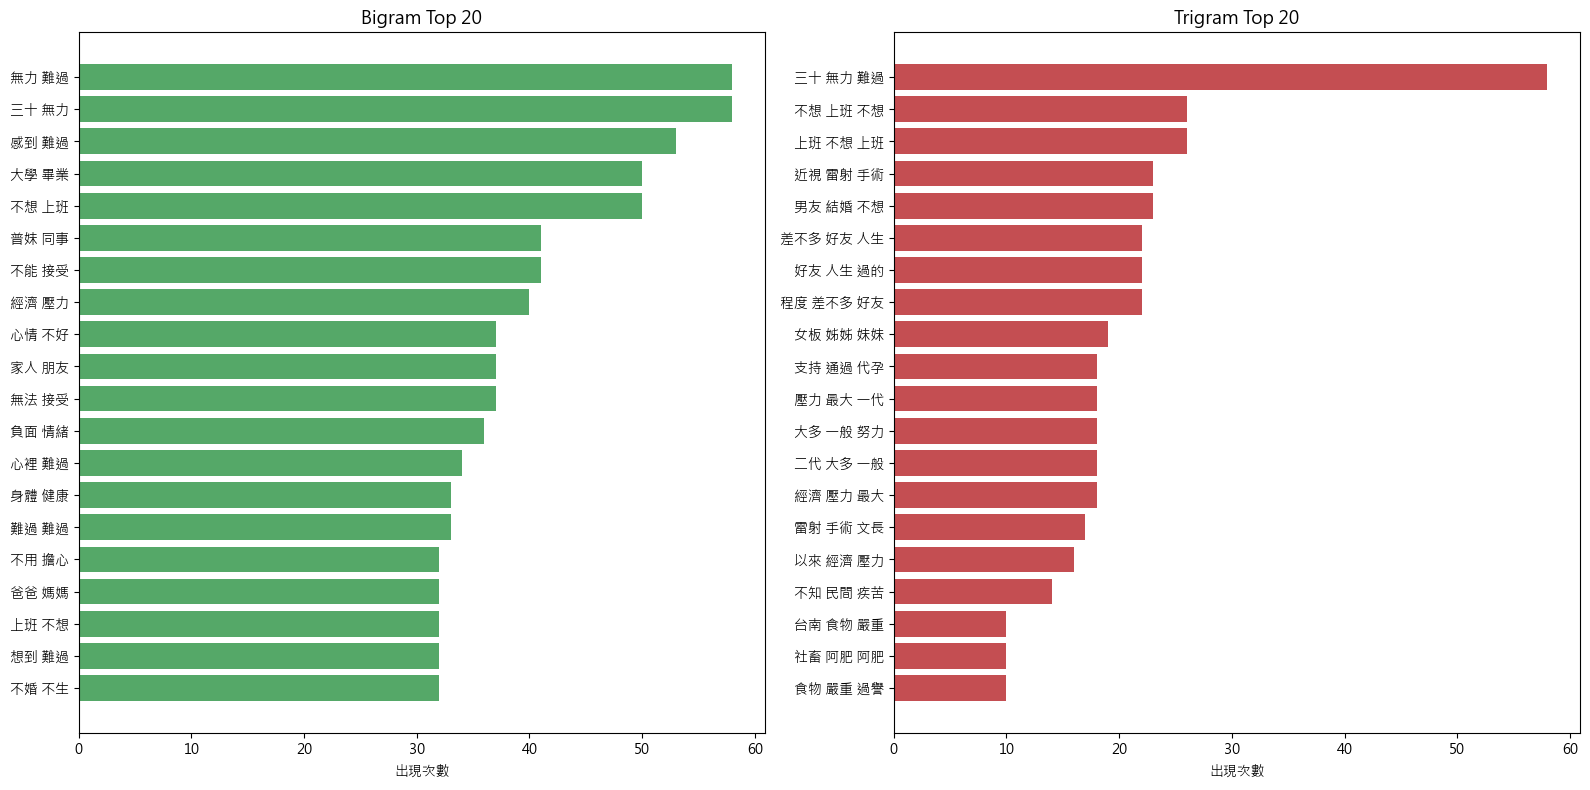

解讀：Bigram 與 Trigram 能揭示具體事件搭配，例如「分手+男友」、「工作+壓力+離職」等。


In [321]:
# P1-2b 視覺化：Bigram & Trigram 並排長條圖

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(19, -1, -1), bigram_top30["count"].head(20), color="#55A868")
axes[0].set_yticks(range(19, -1, -1))
axes[0].set_yticklabels(bigram_top30["bigram"].head(20))
axes[0].set_xlabel("出現次數")
axes[0].set_title("Bigram Top 20", fontsize=13)

axes[1].barh(range(19, -1, -1), trigram_top20["count"], color="#C44E52")
axes[1].set_yticks(range(19, -1, -1))
axes[1].set_yticklabels(trigram_top20["trigram"])
axes[1].set_xlabel("出現次數")
axes[1].set_title("Trigram Top 20", fontsize=13)

plt.tight_layout()
plt.show()

print("解讀：Bigram 與 Trigram 能揭示具體事件搭配，例如「分手+男友」、「工作+壓力+離職」等。")

##
# Part 2. 訓練Word2Vec

讓模型學詞和詞的語意關係



In [323]:
%whos DataFrame

Variable           Type         Data/Info
-----------------------------------------
bigram_top30       DataFrame    Shape: (30, 2)
df                 DataFrame    Shape: (7564, 23)
df_analysis        DataFrame    Shape: (7541, 23)
df_raw             DataFrame    Shape: (7571, 11)
examples           DataFrame    Shape: (3, 6)
family_df          DataFrame    Shape: (80, 3)
friend_df          DataFrame    Shape: (40, 3)
friend_galaxy_df   DataFrame    Shape: (21, 7)
invalid_rows       DataFrame    Shape: (0, 23)
love_df            DataFrame    Shape: (80, 3)
missing_rows       DataFrame    Shape: (7, 11)
missing_table      DataFrame    Shape: (11, 3)
plot_df            DataFrame    Shape: (7, 3)
tag_counts         DataFrame    Shape: (13, 3)
tfidf_top30        DataFrame    Shape: (30, 2)
top30_freq         DataFrame    Shape: (30, 2)
top_tags           DataFrame    Shape: (10, 3)
trigram_top20      DataFrame    Shape: (20, 2)
work_df            DataFrame    Shape: (80, 3)
work_galaxy_df  

In [325]:
df.columns.tolist()

['system_id',
 'artUrl',
 'artTitle',
 'artDate',
 'artPoster',
 'artCatagory',
 'artContent',
 'artComment',
 'e_ip',
 'insertedDate',
 'dataSource',
 'artDate_dt',
 'year',
 'month_of_year',
 'tag',
 'is_reply',
 'is_forward',
 'clean_title',
 'clean_content',
 'analysis_text',
 'text_length',
 'tokens',
 'tokens_str']

In [220]:
print(type(df["tokens"].iloc[0]))
print(df["tokens"].iloc[0])

<class 'list'>
['2020', '12', '步數', '不足', '月實', '太太', '多事', '沒辦', '法多', '走路', '這幾個', '禮拜', '跑步', '步數', '不足', '平均', '一天', '不到', '一萬步', '三十多', '萬步', '而已']


In [327]:
from gensim.models import Word2Vec

token_col = "tokens"

sents = df[token_col].to_list()

# 移除空的斷詞結果
sents = [sent for sent in sents if isinstance(sent, list) and len(sent) > 0]

print("文章數量：", len(sents))
print("第一篇斷詞結果：", sents[0])

w2v_model = Word2Vec(
    sentences=sents,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=20,
    seed=42
)

print("Word2Vec 訓練完成")
print("詞彙數量：", len(w2v_model.wv))

文章數量： 7564
第一篇斷詞結果： ['2020', '12', '步數', '不足', '月實', '太太', '多事', '沒辦', '法多', '走路', '這幾個', '禮拜', '跑步', '步數', '不足', '平均', '一天', '不到', '一萬步', '三十多', '萬步', '而已']
Word2Vec 訓練完成
詞彙數量： 12453


In [328]:
# 找出 tokens 不是 list，或 tokens 是空 list 的文章
invalid_rows = df[
    ~df["tokens"].apply(lambda x: isinstance(x, list) and len(x) > 0)
].copy()

print("被排除的文章數量：", invalid_rows.shape[0])

invalid_rows[["system_id", "artTitle", "artContent", "tokens"]]

被排除的文章數量： 0


,system_id,artTitle,artContent,tokens


In [329]:
print("df_raw 筆數：", df_raw.shape)
print("df 筆數：", df.shape)

df_raw 筆數： (7571, 11)
df 筆數： (7564, 23)


In [333]:
raw_ids = set(df_raw["system_id"])
df_ids = set(df["system_id"])

missing_ids = raw_ids - df_ids

print("df_raw 有但 df 沒有的文章數：", len(missing_ids))
print(missing_ids)

df_raw 有但 df 沒有的文章數： 7
{5441, 388, 2711, 5423, 6836, 5431, 5436}


In [335]:
missing_rows = df_raw[df_raw["system_id"].isin(missing_ids)]

missing_rows[["system_id", "artTitle", "artContent"]]

,system_id,artTitle,artContent
387,388,Re:R:[難過]自殺方案（更新於52樓）,NaN
2710,2711,Re:[難過]職場霸凌導致的重度憂鬱症,NaN
5422,5423,Re:[難過]男友想結婚，但我不想,NaN
5430,5431,Re:[難過]男友想結婚，但我不想,NaN
5435,5436,Re:[難過]男友想結婚，但我不想,NaN
5440,5441,Re:[難過]男友想結婚，但我不想,NaN
6835,6836,[難過]內心受傷怎麼辦,NaN


In [232]:
##檢查詞附近出現的字是不是合理的，確認有沒有需要再調整段詞

In [337]:
target_words = ["朋友", "家人", "媽媽", "爸爸", "男友", "工作", "同事", "公司", "小孩", "壓力", "難過", "一起"]

for word in target_words:
    print("=" * 50)
    print(f"【{word}】")
    
    if word in w2v_model.wv:
        for similar_word, score in w2v_model.wv.most_similar(word, topn=20):
            print(similar_word, round(score, 3))
    else:
        print("這個詞不在 Word2Vec 詞彙表中")

【朋友】
老朋友 0.585
漸遠 0.577
罰款 0.574
漸行 0.573
絕交 0.565
就當 0.543
問一個 0.543
交到 0.536
近況 0.53
嘻嘻哈哈 0.528
封鎖 0.527
問會 0.526
要辦 0.523
另個 0.521
不熟 0.521
寵物溝 0.521
騙子 0.518
哀居 0.514
不會來 0.514
禮物給 0.513
【家人】
口腔癌 0.585
只想養 0.545
拖累 0.543
貓當 0.539
親情 0.527
道別 0.525
沒經過 0.519
不會後悔 0.519
同住 0.516
地步 0.512
裡就 0.504
傳染給 0.502
親友 0.495
除此之外 0.491
很傷 0.49
媽咪 0.487
她後來 0.484
離別 0.482
很累 0.478
兒福 0.473
【媽媽】
我媽媽 0.635
恨意 0.596
苦撐 0.577
拉拉 0.569
風雨 0.562
除夕夜 0.552
單親 0.548
弟弟 0.542
訴說 0.536
不幫 0.535
爸爸 0.534
聚在一起 0.531
過母 0.527
富媽媽 0.526
他媽媽 0.525
婆家 0.522
不怪 0.521
弟媳 0.519
姑姑 0.517
親口 0.516
【爸爸】
富媽媽 0.574
父女 0.544
媽媽 0.534
有富 0.532
兄妹 0.515
苦撐 0.514
恨意 0.504
愛賭 0.494
自強 0.49
加護 0.486
精子 0.485
他爸 0.484
親節 0.478
我媽媽 0.478
盡到 0.477
老媽 0.475
過母 0.475
訴說 0.474
單親 0.472
往生 0.468
【男友】
找人 0.577
前女友 0.557
刷馬桶 0.53
未婚夫 0.519
還幫 0.51
男兒 0.508
過一個 0.507
性生活 0.503
不花 0.5
慶生 0.496
還願 0.493
頭七 0.491
送禮 0.489
學姐 0.486
甜蜜 0.486
戒指 0.486
林秉樞 0.48
介紹給 0.478
求婚 0.475
追問 0.473
【工作】
第一份 0.662
四萬 0.603
行屍 0.6
調動 0.596
輪班 0.595
鐵飯 

In [339]:
# 計算兩個字之間的關係
w2v_model.wv.similarity("朋友","家人")

0.35141084

In [341]:
# 比較字詞間，誰最不相關（邊緣）
w2v_model.wv.doesnt_match(["壓力很大", "朋友", '家人'])

'朋友'

In [343]:
# 相對關係
w2v_model.wv.most_similar(positive=["朋友"], negative=["家人"], topn=5)

[('討厭', 0.2947770953178406),
 ('大學生', 0.2777422070503235),
 ('西斯', 0.2758547067642212),
 ('打算', 0.2720273733139038),
 ('到後面', 0.2700182795524597)]

[('討厭', 0.2947770953178406), ('大學生', 0.2777422070503235), ('西斯', 0.2758547067642212), ('打算', 0.2720273733139038), ('到後面', 0.2700182795524597)]
  word      dim1      dim2
0   朋友  0.524610  0.238515
1   家人  3.093559  0.950842
2   討厭 -0.788911 -1.244190
3  大學生 -0.689615 -1.381956
4   西斯 -0.181727 -0.686305
5   打算 -1.909899  2.698327
6  到後面 -0.048019 -0.575232


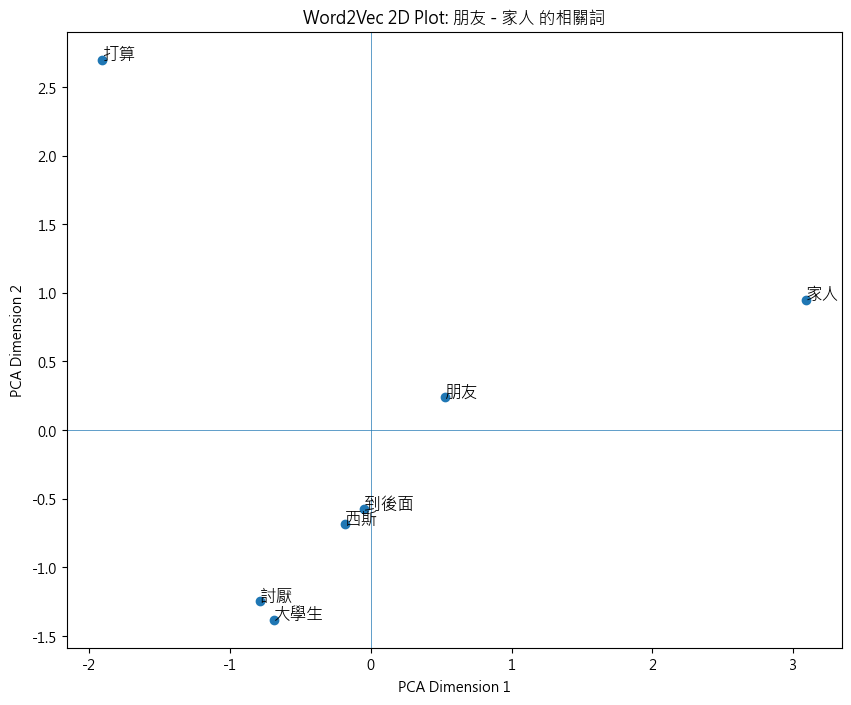

In [345]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. 先取得「朋友 - 家人」最接近的詞
result = w2v_model.wv.most_similar(
    positive=["朋友"],
    negative=["家人"],
    topn=5
)

print(result)

# 2. 整理要畫的詞
base_words = ["朋友", "家人"]
related_words = [w for w, s in result]
plot_words = base_words + related_words

# 3. 過濾掉不在詞彙表中的詞
plot_words = [w for w in plot_words if w in w2v_model.wv]

# 4. 取出詞向量
vecs = np.array([w2v_model.wv[w] for w in plot_words])

# 5. PCA 降成 2 維
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vecs)

# 6. 建立 DataFrame
plot_df = pd.DataFrame({
    "word": plot_words,
    "dim1": coords[:, 0],
    "dim2": coords[:, 1]
})

print(plot_df)

# 7. 畫圖
plt.figure(figsize=(10, 8))

plt.scatter(plot_df["dim1"], plot_df["dim2"])

for _, row in plot_df.iterrows():
    plt.text(row["dim1"], row["dim2"], row["word"], fontsize=12)

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

plt.title("Word2Vec 2D Plot: 朋友 - 家人 的相關詞")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.show()

In [347]:
# 取得所有的字
words = w2v_model.wv.key_to_index.keys()

In [349]:
# 降維：利用PCA tSNE

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 25,learning_rate = 400):

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0),
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate),
    }
    new_feat = method_dict[method].fit_transform(mat)

    return new_feat


In [351]:
# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        vecs.append(model.wv[i])
    return np.vstack(vecs)


In [353]:
getVecs(w2v_model, [
    "朋友",
    "家人",  "前女友", "交往","工作", 
])

array([[-2.10563377e-01, -6.42824173e-01,  1.49844870e-01,
         4.11210861e-03, -7.83608556e-02,  8.42442364e-02,
         1.74672365e-01,  9.53511149e-02, -1.55903473e-01,
         8.25968236e-02, -4.79626358e-01, -1.12053432e-01,
        -1.28356010e-01, -1.41437009e-01, -1.49278585e-02,
        -2.02856347e-01,  9.14505348e-02, -5.15761554e-01,
         7.14661106e-02, -2.33341962e-01, -3.50845084e-02,
         1.26740336e-01,  3.69775221e-02,  1.96590438e-01,
         4.71647203e-01, -1.25818044e-01, -3.33137482e-01,
         1.53103605e-01,  1.65096119e-01, -1.63254142e-03,
         3.90800625e-01, -4.48737562e-01, -8.77261519e-01,
         2.90961504e-01,  1.71544522e-01,  3.44174020e-02,
         4.82588500e-01, -5.46192169e-01,  1.59079701e-01,
         6.21767752e-02,  7.17293248e-02,  2.78949827e-01,
         1.72304749e-01,  8.61291811e-02,  6.91330671e-01,
         4.86509383e-01, -3.02678704e-01, -3.94954145e-01,
         5.65403104e-01, -9.55399156e-01,  2.51068145e-0

#語意詞表擴展
模型幾個核心詞，然後讓 Word2Vec 自動找出相似詞，形成不同主題的詞群。

In [355]:
# 擴展相似的字詞
import pandas as pd

def expand_words_df(model, seed_words, top_n=20):
    results = []

    for seed in seed_words:
        if seed not in model.wv:
            results.append({
                "seed_word": seed,
                "similar_word": "不在詞彙表中",
                "score": None
            })
            continue

        similar_words = model.wv.most_similar(seed, topn=top_n)

        for word, score in similar_words:
            results.append({
                "seed_word": seed,
                "similar_word": word,
                "score": round(score, 4)
            })

    return pd.DataFrame(results)

In [357]:
friend_df = expand_words_df(w2v_model, ["朋友", "老朋友"], top_n=20)
family_df = expand_words_df(w2v_model, ["家人", "媽媽", "爸爸", "父母"], top_n=20)
work_df = expand_words_df(w2v_model, ["工作", "公司", "同事", "主管"], top_n=20)
love_df = expand_words_df(w2v_model, ["男友", "女友", "交往", "分手"], top_n=20)

In [359]:
display(friend_df)
display(family_df)
display(work_df)
display(love_df)

,seed_word,similar_word,score
0,朋友,老朋友,0.5848
1,朋友,漸遠,0.5774
2,朋友,罰款,0.5737
3,朋友,漸行,0.5731
4,朋友,絕交,0.5646
5,朋友,就當,0.5432
6,朋友,問一個,0.5429
7,朋友,交到,0.5363
8,朋友,近況,0.5296
9,朋友,嘻嘻哈哈,0.5281


,seed_word,similar_word,score
0,家人,口腔癌,0.5847
1,家人,只想養,0.5455
2,家人,拖累,0.5434
3,家人,貓當,0.5387
4,家人,親情,0.5275
...,...,...,...
75,父母,內疚,0.5198
76,父母,林奕含,0.5173
77,父母,失利,0.5171
78,父母,內言,0.5152


,seed_word,similar_word,score
0,工作,第一份,0.6616
1,工作,四萬,0.6034
2,工作,行屍,0.6002
3,工作,調動,0.5961
4,工作,輪班,0.5948
...,...,...,...
75,主管,值班,0.5209
76,主管,業績,0.5195
77,主管,公事,0.5170
78,主管,一視,0.5168


,seed_word,similar_word,score
0,男友,找人,0.5767
1,男友,前女友,0.5570
2,男友,刷馬桶,0.5297
3,男友,未婚夫,0.5185
4,男友,還幫,0.5102
...,...,...,...
75,分手,求婚,0.5474
76,分手,妓女,0.5465
77,分手,斷聯,0.5464
78,分手,前男友,0.5427


In [361]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px

# =====================================================
# 1. 建立單一核心詞的 3D 銀河圖函數
# =====================================================

def plot_word_galaxy_3d(model, seed_word, top_n=20, method="PCA"):
    """
    model: Word2Vec 模型
    seed_word: 核心詞，例如 "朋友"
    top_n: 找出前幾個相似詞
    method: 目前使用 PCA 降維
    """

    # 檢查核心詞是否在詞彙表中
    if seed_word not in model.wv:
        print(f"「{seed_word}」不在 Word2Vec 詞彙表中")
        return None

    # 取得相似詞
    similar_words = model.wv.most_similar(seed_word, topn=top_n)

    # 整理詞表：核心詞 + 相似詞
    words = [seed_word] + [w for w, score in similar_words]

    # 取得相似度分數
    scores = [1.0] + [score for w, score in similar_words]

    # 標記核心詞與相似詞
    word_type = ["核心詞"] + ["相似詞"] * len(similar_words)

    # 取得詞向量
    vecs = np.array([model.wv[w] for w in words])

    # PCA 降成 3 維
    pca = PCA(n_components=3, random_state=42)
    coords = pca.fit_transform(vecs)

    # 建立 DataFrame
    word_df = pd.DataFrame({
        "word": words,
        "similarity_to_seed": scores,
        "type": word_type,
        "dim1": coords[:, 0],
        "dim2": coords[:, 1],
        "dim3": coords[:, 2]
    })

    # 點大小：核心詞比較大，相似詞依相似度調整
    word_df["size"] = word_df["similarity_to_seed"].apply(lambda x: 18 if x == 1.0 else 8 + x * 10)

    # 畫 3D 圖
    fig = px.scatter_3d(
        word_df,
        x="dim1",
        y="dim2",
        z="dim3",
        color="type",
        size="size",
        text="word",
        hover_name="word",
        hover_data=["similarity_to_seed"],
        width=1000,
        height=800,
        title=f"Word2Vec 3D 詞語銀河圖：{seed_word}"
    )

    fig.update_traces(
        textposition="top center"
    )

    fig.show(config={
        "displayModeBar": True,
        "scrollZoom": True,
        "displaylogo": False
    })

    return word_df

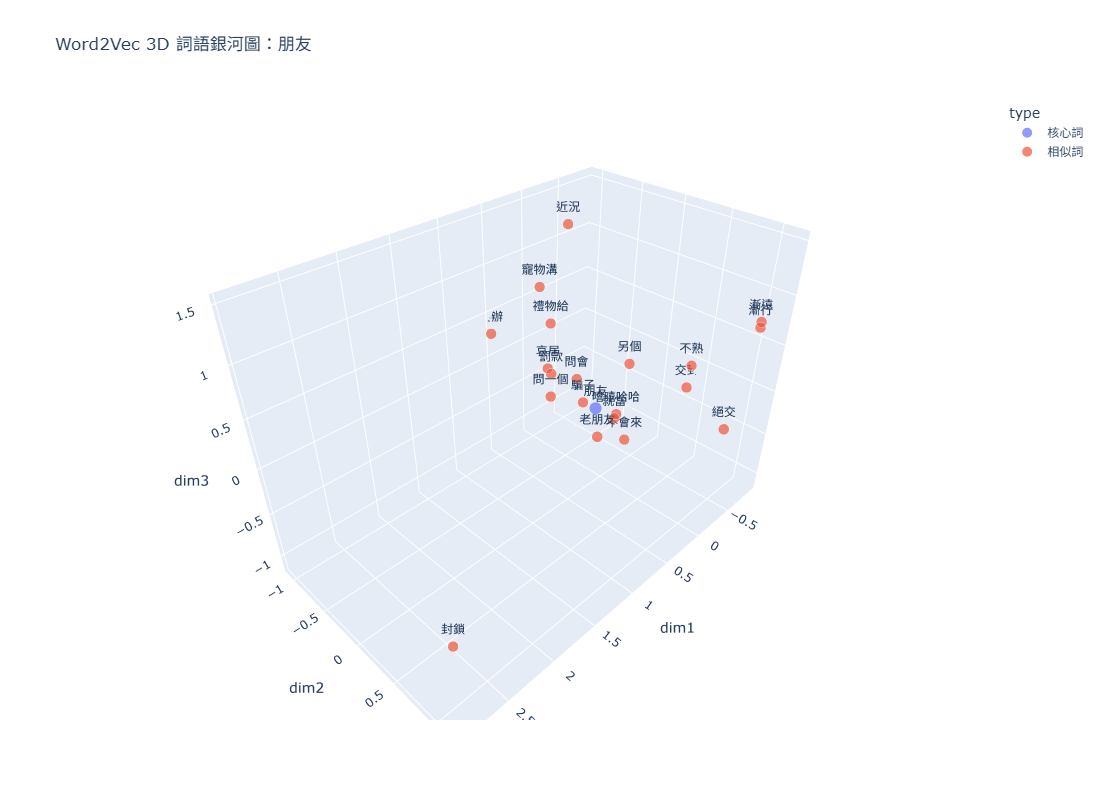

In [363]:
friend_galaxy_df = plot_word_galaxy_3d(
    model=w2v_model,
    seed_word="朋友",
    top_n=20
)

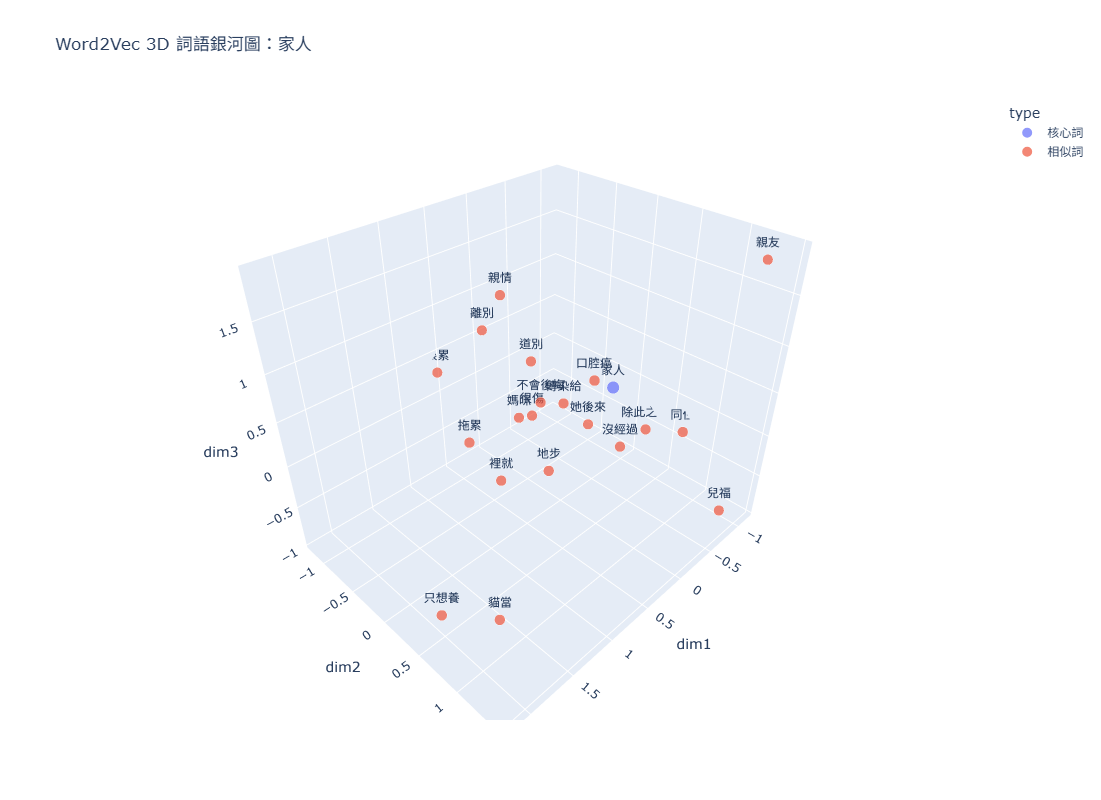

In [365]:
family_galaxy_df = plot_word_galaxy_3d(
    model=w2v_model,
    seed_word="家人",
    top_n=20
)

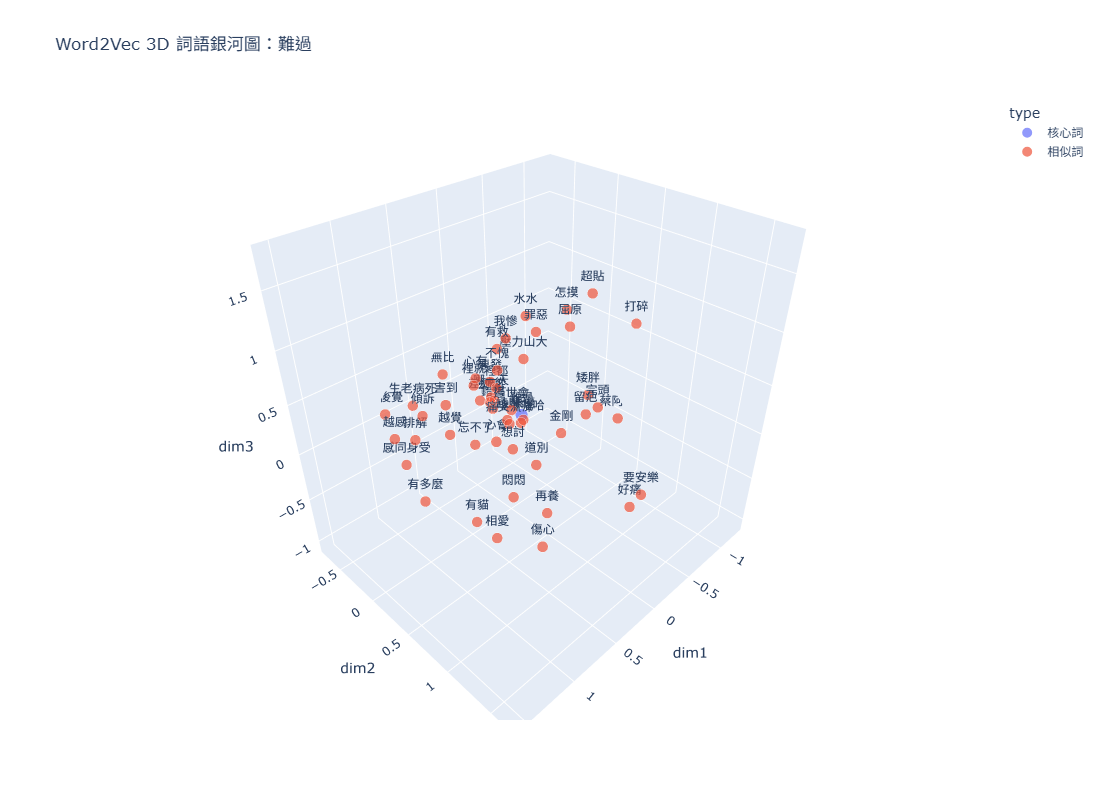

In [369]:
family_galaxy_df = plot_word_galaxy_3d(
    model=w2v_model,
    seed_word="難過",
    top_n=50
)

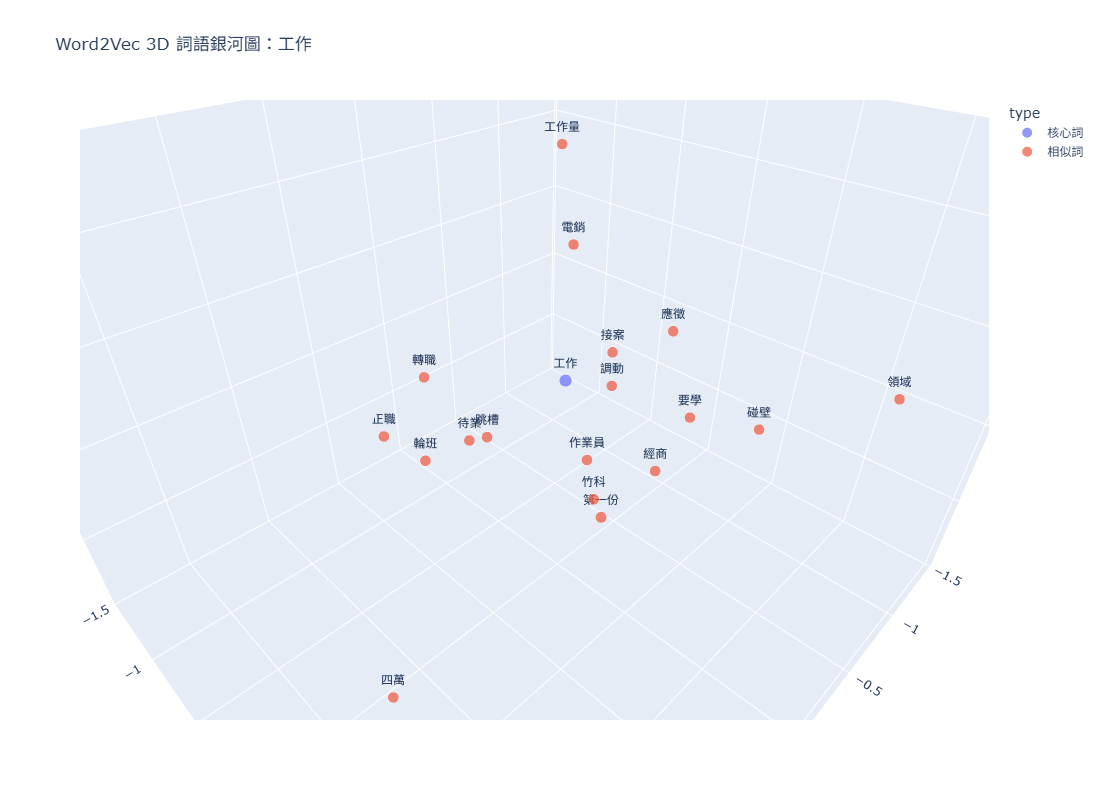

In [266]:
work_galaxy_df = plot_word_galaxy_3d(
    model=w2v_model,
    seed_word="工作",
    top_n=20
)

In [ ]:
#在你的 PTT WomenTalk「難過」貼文資料中，「朋友」和「絕交」常出現在相似的上下文裡，所以模型把它們放得比較近。


## 二維圖




In [97]:
import sys
!{sys.executable} -m pip install plotly

In [99]:
import plotly.express as px

In [101]:
import sys

print("目前 Notebook 使用的 Python：")
print(sys.executable)

!{sys.executable} -m pip install plotly

目前 Notebook 使用的 Python：
C:\Users\uh52j\anaconda3\envs\sma2026\python.exe


In [103]:
import plotly
import plotly.express as px

print(plotly.__version__)

6.7.0


In [105]:
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA

# 1. 取出 Word2Vec 模型中的前 200 個高頻詞
top_n = 200
top_words = w2v_model.wv.index_to_key[:top_n]

print("取出的高頻詞數量：", len(top_words))
print(top_words[:20])

取出的高頻詞數量： 200
['朋友', '工作', '不要', '發現', '小孩', '時間', '不能', '一起', '喜歡', '直接', '公司', '同事', '只能', '生活', '想到', '上班', '女生', '不想', '好像', '完全']


In [107]:
# 2. 取得這 200 個詞的 Word2Vec 向量
vecs = []

for word in top_words:
    vecs.append(w2v_model.wv[word])

vecs

[array([ 0.11288291,  0.44717836,  0.18273331, -0.07967906, -0.09277649,
         0.28805268, -0.25430688,  0.7007423 , -0.21270579, -0.33799264,
         0.06171361,  0.2540182 ,  0.2609644 ,  0.32508558, -0.08151484,
         0.31724393, -0.04017137, -0.616207  ,  0.26645002,  0.39219925,
         0.10715405, -0.11825372, -0.3967257 , -0.13152595,  0.34409222,
         0.42074302, -0.11964167,  0.07480516, -0.09551272,  0.01362826,
        -0.2982027 , -0.5307109 , -0.18924516,  0.3536448 ,  0.78434426,
        -0.26976898,  0.30756426,  0.03418633,  0.04283251,  0.00212394,
        -0.36879426, -0.04045164,  0.4687971 , -0.30202964,  0.01097504,
         0.06067919,  0.37043083,  0.47055587,  0.3127637 , -0.15486677,
         0.39193398, -0.7550481 , -0.31847334,  0.06185904,  0.04808883,
         0.11477911,  0.13189766, -0.0331777 , -0.07812297, -0.07319579,
         0.13634858,  0.23592693,  0.29467544,  0.23136032, -0.20940694,
         0.22911313,  0.13248591, -0.04169953, -0.4

In [109]:
# 3. 用 PCA 降成 2 維
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vecs)

# 4. 整理成 DataFrame
word_df = pd.DataFrame({
    "word": top_words,
    "dim1": coords[:, 0],
    "dim2": coords[:, 1],
    "count": [w2v_model.wv.get_vecattr(word, "count") for word in top_words]
})

word_df.head()

,word,dim1,dim2,count
0,朋友,0.370639,0.023784,1797
1,工作,0.468767,0.630292,1795
2,不要,-0.363519,0.245947,1604
3,發現,0.025751,-0.226883,1167
4,小孩,0.551222,0.577038,1030


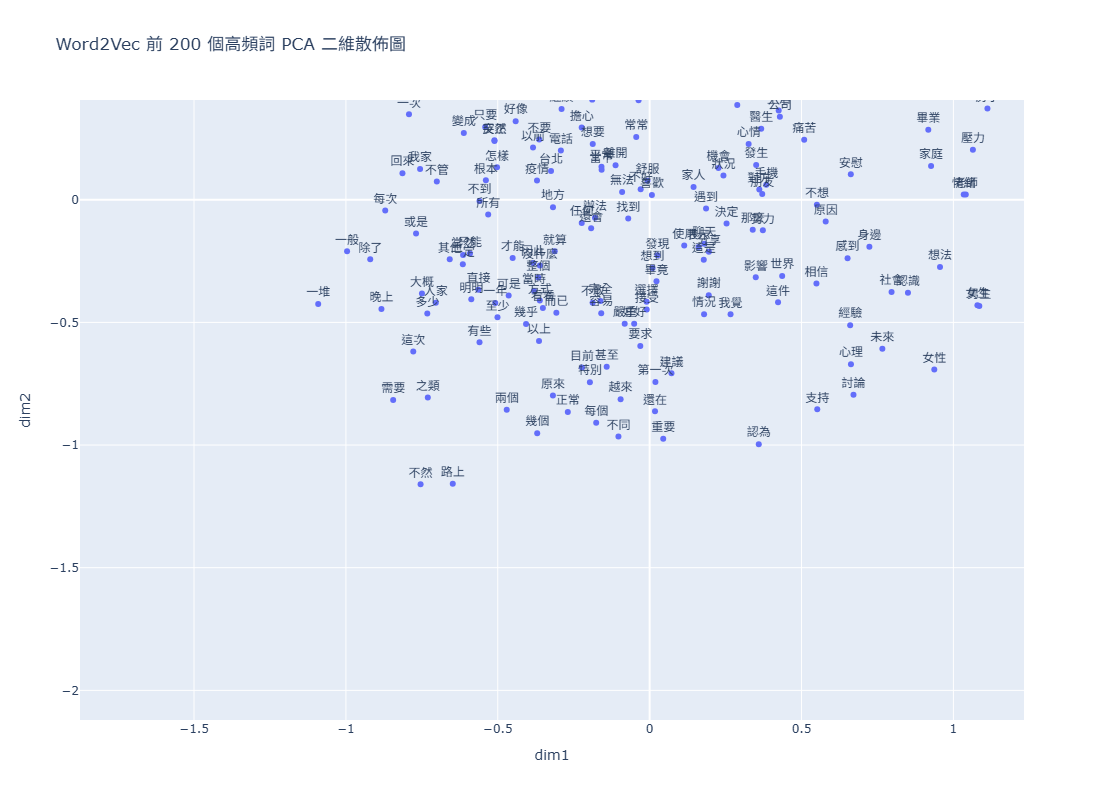

In [111]:
# 5. 畫出前 200 個高頻詞的互動式二維圖
fig = px.scatter(
    word_df,
    x="dim1",
    y="dim2",
    text="word",
    hover_name="word",
    hover_data=["count"],
    width=1000,
    height=800,
    title="Word2Vec 前 200 個高頻詞 PCA 二維散佈圖"
)

fig.update_traces(
    marker=dict(size=6),
    textposition="top center"
)

fig.update_layout(
    dragmode="zoom"
)

fig.show(config={
    "displayModeBar": True,
    "scrollZoom": True,
    "displaylogo": False
})

##**探討:女生的難過是否與朋友和家人有關？**

保留下來的詞數： 25
保留下來的詞：
['朋友', '老朋友', '聚會', '絕交', '封鎖', '認識', '疏遠', '陪伴', '閨蜜', '家人', '媽媽', '爸爸', '父母', '親情', '同住', '手足', '爸媽', '傷心', '孤單', '失望', '痛苦', '壓力', '委屈', '崩潰', '情緒']


,word,dim1,dim2,category
0,朋友,-0.965920,-0.730561,朋友相關
1,老朋友,-0.746968,-0.700538,朋友相關
2,聚會,-1.539638,-0.319937,朋友相關
3,絕交,-0.842044,-0.115695,朋友相關
4,封鎖,-2.037405,-1.879134,朋友相關


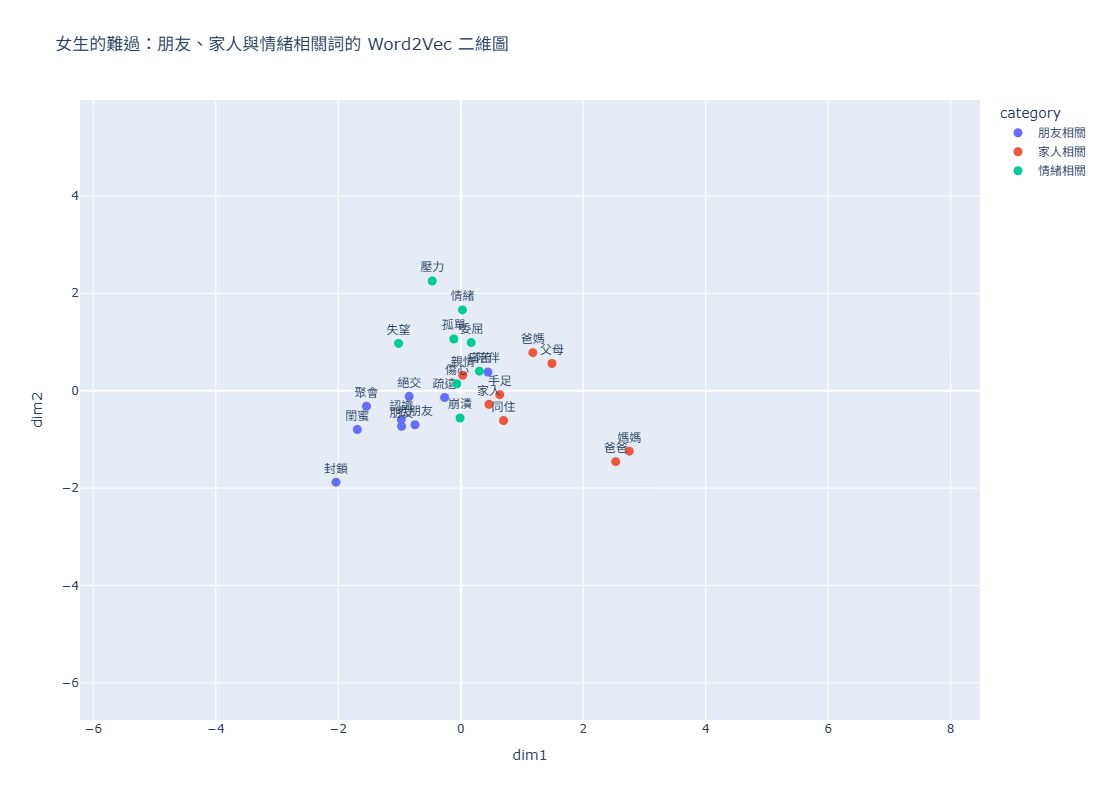

這張 PCA 二維圖顯示，在你的 Word2Vec 模型中，「親情」和「傷心」被投影到相近的位置，代表它們在資料中的語境可能比較接近。


In [116]:
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px

# =========================================================
# 1. 設定和研究題目有關的詞
# 題目：女生的難過是否與朋友和家人有關？
# =========================================================

friend_words = [
    "朋友", "老朋友", "聚會", "絕交", "封鎖", "認識", "疏遠", "陪伴", "閨蜜"
]

family_words = [
    "家人", "媽媽", "爸爸", "父母", "親情", "同住", "手足", "爸媽"
]

emotion_words = [
    "難過", "傷心", "孤單", "失望", "痛苦", "壓力", "委屈", "崩潰", "哭", "情緒"
]

selected_words = friend_words + family_words + emotion_words


# =========================================================
# 2. 只保留 Word2Vec 模型裡真的存在的詞
# =========================================================

selected_words = [w for w in selected_words if w in w2v_model.wv]

print("保留下來的詞數：", len(selected_words))
print("保留下來的詞：")
print(selected_words)


# =========================================================
# 3. 幫每個詞加上類別
# =========================================================

word_category = {}

for word in friend_words:
    word_category[word] = "朋友相關"

for word in family_words:
    word_category[word] = "家人相關"

for word in emotion_words:
    word_category[word] = "情緒相關"


# =========================================================
# 4. 取出詞向量
# =========================================================

vecs = [w2v_model.wv[word] for word in selected_words]


# =========================================================
# 5. PCA 降成 2 維
# =========================================================

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vecs)


# =========================================================
# 6. 整理成 DataFrame
# =========================================================

word_df = pd.DataFrame({
    "word": selected_words,
    "dim1": coords[:, 0],
    "dim2": coords[:, 1]
})

word_df["category"] = word_df["word"].map(word_category)

display(word_df.head())


# =========================================================
# 7. 畫互動式二維圖
# =========================================================

fig = px.scatter(
    word_df,
    x="dim1",
    y="dim2",
    color="category",
    text="word",
    hover_name="word",
    width=1000,
    height=800,
    title="女生的難過：朋友、家人與情緒相關詞的 Word2Vec 二維圖"
)

fig.update_traces(
    marker=dict(size=9),
    textposition="top center"
)

fig.update_layout(
    dragmode="zoom"
)

fig.show(config={
    "displayModeBar": True,
    "scrollZoom": True,
    "displaylogo": False
})

print("這張 PCA 二維圖顯示，在你的 Word2Vec 模型中，「親情」和「傷心」被投影到相近的位置，代表它們在資料中的語境可能比較接近。")




## 三維圖




取出的高頻詞數量： 200
前 20 個高頻詞：
['朋友', '工作', '不要', '發現', '小孩', '時間', '不能', '一起', '喜歡', '直接', '公司', '同事', '只能', '生活', '想到', '上班', '女生', '不想', '好像', '完全']


,word,dim1,dim2,dim3,count
0,朋友,0.370639,0.023784,-0.036707,1797
1,工作,0.468767,0.630292,0.135890,1795
2,不要,-0.363519,0.245947,-0.188526,1604
3,發現,0.025751,-0.226883,1.222211,1167
4,小孩,0.551222,0.577038,-0.469031,1030


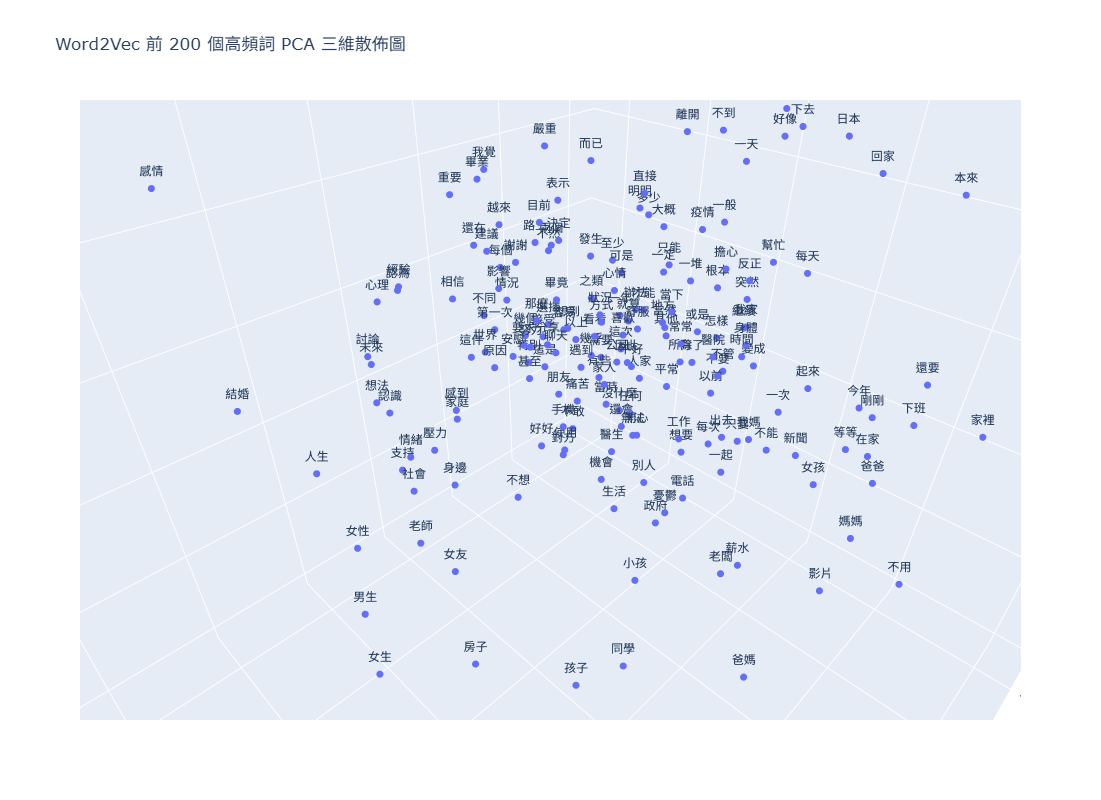

In [119]:
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px

# =========================================================
# 1. 取出 Word2Vec 模型中的前 200 個高頻詞
# =========================================================

top_n = 200
top_words = w2v_model.wv.index_to_key[:top_n]

print("取出的高頻詞數量：", len(top_words))
print("前 20 個高頻詞：")
print(top_words[:20])


# =========================================================
# 2. 取得這 200 個詞的 Word2Vec 向量
# =========================================================

vecs = [w2v_model.wv[word] for word in top_words]


# =========================================================
# 3. PCA 降成 3 維
# =========================================================

pca = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(vecs)


# =========================================================
# 4. 整理成 DataFrame
# =========================================================

word_3d_df = pd.DataFrame({
    "word": top_words,
    "dim1": coords[:, 0],
    "dim2": coords[:, 1],
    "dim3": coords[:, 2],
    "count": [w2v_model.wv.get_vecattr(word, "count") for word in top_words]
})

display(word_3d_df.head())


# =========================================================
# 5. 畫 3D 互動式散佈圖
# =========================================================

fig = px.scatter_3d(
    word_3d_df,
    x="dim1",
    y="dim2",
    z="dim3",
    text="word",
    hover_name="word",
    hover_data=["count"],
    width=1000,
    height=800,
    title="Word2Vec 前 200 個高頻詞 PCA 三維散佈圖"
)

fig.update_traces(
    marker=dict(size=4),
    textposition="top center"
)

fig.show(config={
    "displayModeBar": True,
    "scrollZoom": True,
    "displaylogo": False
})

##**探討:女生的難過是否與朋友和家人有關？**

保留下來的詞數： 26
保留下來的詞：
['朋友', '老朋友', '聚會', '絕交', '封鎖', '認識', '疏遠', '陪伴', '閨蜜', '家人', '媽媽', '爸爸', '父母', '親情', '同住', '手足', '爸媽', '難過', '傷心', '孤單', '失望', '痛苦', '壓力', '委屈', '崩潰', '情緒']


,word,dim1,dim2,dim3,category
0,朋友,-0.995074,-0.227010,-0.719971,朋友相關
1,老朋友,-0.876894,-0.394844,-0.421443,朋友相關
2,聚會,-1.305021,0.046499,-1.230170,朋友相關
3,絕交,-0.892777,-0.455843,0.164367,朋友相關
4,封鎖,-2.257927,-0.390376,-0.166350,朋友相關


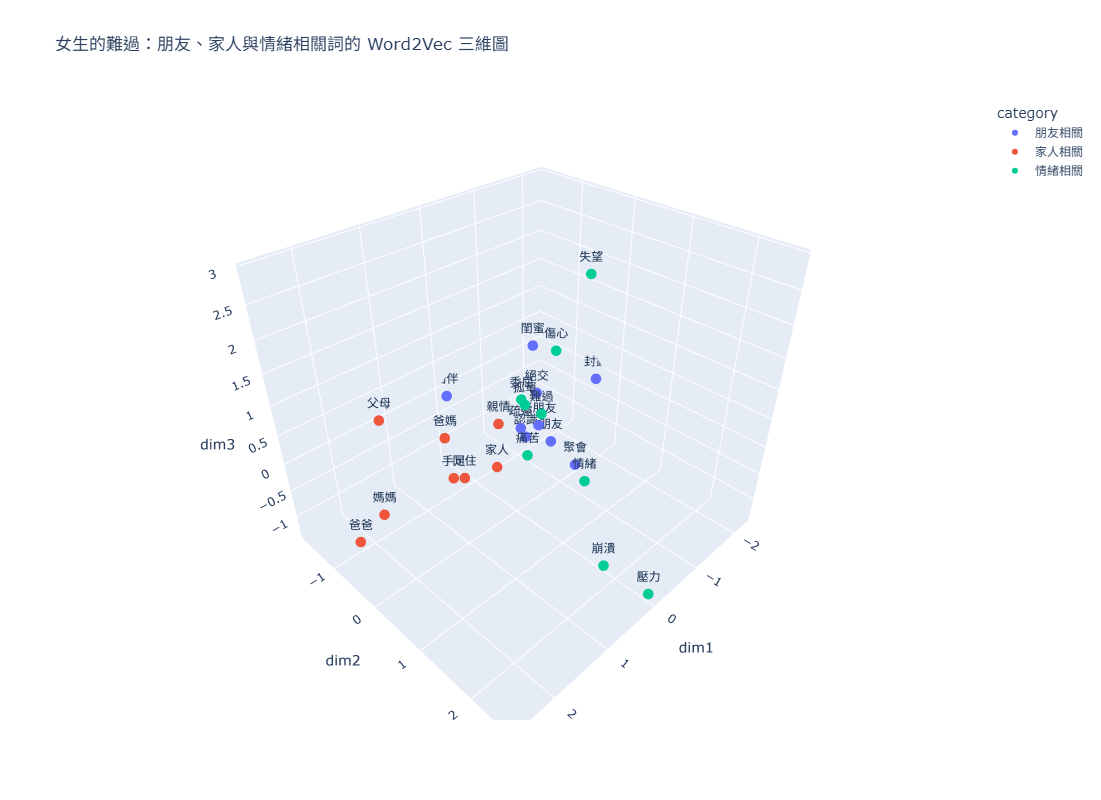

In [371]:
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px

# =========================================================
# 1. 設定和研究題目有關的詞
# 題目：女生的難過是否與朋友和家人有關？
# =========================================================

friend_words = [
    "朋友", "老朋友", "聚會", "絕交", "封鎖", "認識", "疏遠", "陪伴", "閨蜜"
]

family_words = [
    "家人", "媽媽", "爸爸", "父母", "親情", "同住", "手足", "爸媽"
]

emotion_words = [
    "難過", "傷心", "孤單", "失望", "痛苦", "壓力", "委屈", "崩潰", "哭", "情緒"
]

selected_words = friend_words + family_words + emotion_words


# =========================================================
# 2. 只保留 Word2Vec 模型裡真的存在的詞
# =========================================================

selected_words = [w for w in selected_words if w in w2v_model.wv]

print("保留下來的詞數：", len(selected_words))
print("保留下來的詞：")
print(selected_words)


# =========================================================
# 3. 幫每個詞加上類別
# =========================================================

word_category = {}

for word in friend_words:
    word_category[word] = "朋友相關"

for word in family_words:
    word_category[word] = "家人相關"

for word in emotion_words:
    word_category[word] = "情緒相關"


# =========================================================
# 4. 取得詞向量
# =========================================================

vecs = [w2v_model.wv[word] for word in selected_words]


# =========================================================
# 5. PCA 降成 3 維
# =========================================================

pca = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(vecs)


# =========================================================
# 6. 整理成 DataFrame
# =========================================================

word_3d_df = pd.DataFrame({
    "word": selected_words,
    "dim1": coords[:, 0],
    "dim2": coords[:, 1],
    "dim3": coords[:, 2]
})

word_3d_df["category"] = word_3d_df["word"].map(word_category)

display(word_3d_df.head())


# =========================================================
# 7. 畫 3D 互動式散佈圖
# =========================================================

fig = px.scatter_3d(
    word_3d_df,
    x="dim1",
    y="dim2",
    z="dim3",
    color="category",
    text="word",
    hover_name="word",
    width=1000,
    height=800,
    title="女生的難過：朋友、家人與情緒相關詞的 Word2Vec 三維圖"
)

fig.update_traces(
    marker=dict(size=6),
    textposition="top center"
)

fig.show(config={
    "displayModeBar": True,
    "scrollZoom": True,
    "displaylogo": False
})

In [373]:
target_words = [
    "朋友", "老朋友", "閨蜜", "疏遠", "封鎖", "聚會",
    "家人", "爸媽", "親情", "手足",
    "孤單", "委屈", "傷心", "失望", "痛苦"
]

result = []

for word in target_words:
    if word in w2v_model.wv.key_to_index:
        sim = w2v_model.wv.similarity("難過", word)
        result.append([word, sim])
    else:
        result.append([word, None])

similarity_df = pd.DataFrame(result, columns=["word", "similarity_to_難過"])
similarity_df = similarity_df.sort_values("similarity_to_難過", ascending=False)

similarity_df

,word,similarity_to_難過
12,傷心,0.612018
1,老朋友,0.455690
11,委屈,0.448099
3,疏遠,0.393926
0,朋友,0.391175
14,痛苦,0.361847
4,封鎖,0.352551
6,家人,0.338663
13,失望,0.322234
9,手足,0.316290


##**在這批「難過」貼文中，朋友相關語境可能和情緒經驗有關，尤其可能涉及人際互動、關係變化、疏遠、封鎖、絕交等情境。但還不能說：女生難過主要都是朋友造成的。因為「朋友」也可能是支持者，例如陪伴、安慰、傾聽，不一定是傷害來源。**

In [125]:
pairs = [
    ("朋友", "難過"),
    ("朋友", "傷心"),
    ("朋友", "孤單"),
    ("朋友", "委屈"),
    ("家人", "難過"),
    ("家人", "傷心"),
    ("家人", "壓力"),
    ("家人", "委屈"),
    ("男友", "難過"),
    ("工作", "壓力"),
    ("同事", "委屈")
]

for w1, w2 in pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        score = w2v_model.wv.similarity(w1, w2)
        print(f"{w1} - {w2}: {score:.3f}")
    else:
        print(f"{w1} - {w2}: 有詞不在詞彙表中")

朋友 - 難過: 有詞不在詞彙表中
朋友 - 傷心: 0.392
朋友 - 孤單: 0.349
朋友 - 委屈: 0.169
家人 - 難過: 有詞不在詞彙表中
家人 - 傷心: 0.371
家人 - 壓力: 0.196
家人 - 委屈: 0.332
男友 - 難過: 有詞不在詞彙表中
工作 - 壓力: 0.394
同事 - 委屈: 0.141


In [109]:
pairs = [
    ("媽媽", "傷心"),
    ("媽媽", "委屈"),
    ("媽媽", "壓力"),
    ("爸爸", "傷心"),
    ("爸爸", "委屈"),
    ("父母", "壓力"),
    ("爸媽", "壓力"),
    ("親情", "傷心"),
    ("手足", "委屈"),
    ("朋友", "傷心"),
    ("老朋友", "孤單"),
    ("絕交", "傷心"),
    ("封鎖", "傷心"),
    ("工作", "壓力"),
    ("公司", "壓力"),
    ("主管", "壓力"),
    ("寵物", "壓力"),
    ("寵物", "孤單")
]

for w1, w2 in pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        score = w2v_model.wv.similarity(w1, w2)
        print(f"{w1} - {w2}: {score:.3f}")
    else:
        print(f"{w1} - {w2}: 有詞不在詞彙表中")

媽媽 - 傷心: 0.235
媽媽 - 委屈: 0.203
媽媽 - 壓力: 0.123
爸爸 - 傷心: 0.128
爸爸 - 委屈: 0.170
父母 - 壓力: 0.162
爸媽 - 壓力: 0.271
親情 - 傷心: 0.369
手足 - 委屈: 0.357
朋友 - 傷心: 0.317
老朋友 - 孤單: 0.369
絕交 - 傷心: 0.563
封鎖 - 傷心: 0.341
工作 - 壓力: 0.433
公司 - 壓力: 0.179
主管 - 壓力: 0.192
寵物 - 壓力: 0.160
寵物 - 孤單: 0.333


**#在這批「難過」貼文中，「朋友」不一定直接和「難過」這個詞連在一起，但朋友相關的事件詞，例如「絕交」「封鎖」「老朋友」「孤單」，和情緒詞的關聯較明顯。這表示朋友相關難過可能常透過「關係斷裂、疏離、被排除」這類事件呈現。
#家人相關詞和情緒詞有關，但不像「絕交－傷心」那麼集中或強烈。家人語境可能不是單一情緒，而是分散在媽媽、爸爸、父母、親情、手足等不同家庭角色中。
#目前結果顯示，朋友相關的「關係斷裂」語境最明顯，例如「絕交－傷心」相似度為 0.522；家人相關詞和情緒詞也有關聯，但較分散；此外「工作－壓力」也達 0.394，表示難過來源不只朋友與家人。**



##  t-SNE + 分群 + Plotly




詞數量： 200
詞向量矩陣 shape： (200, 100)


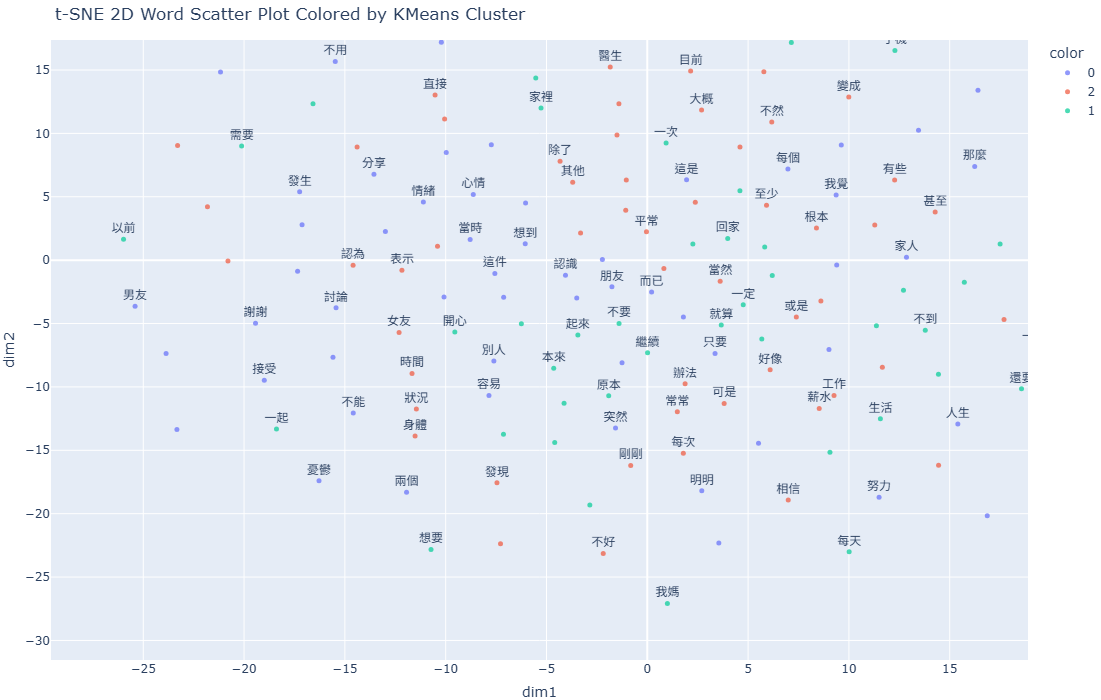

In [136]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import plotly.express as px

# =========================================================
# 1. 建立 sample_words 和 feat
# 使用 Word2Vec 前 200 個高頻詞
# =========================================================

top_n = 200
sample_words = w2v_model.wv.index_to_key[:top_n]

# feat 是詞向量矩陣
feat = np.array([w2v_model.wv[word] for word in sample_words])

print("詞數量：", len(sample_words))
print("詞向量矩陣 shape：", feat.shape)


# =========================================================
# 2. 分群函式：使用 KMeans
# =========================================================

def cluster(X, n=3):
    model = KMeans(n_clusters=n, random_state=0)
    model.fit(X)
    return model.predict(X)


# =========================================================
# 3. t-SNE 降維
# =========================================================

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

d2_feat = tsne.fit_transform(feat)


# =========================================================
# 4. 移除離群點，保留 85%
# =========================================================

distances = np.linalg.norm(d2_feat, axis=1)
threshold = np.percentile(distances, 85)
mask = distances < threshold


# =========================================================
# 5. 分群，只對保留的點
# =========================================================

filtered_feat = feat[mask]
filtered_words = np.array(sample_words)[mask]
filtered_d2 = d2_feat[mask]

colors = cluster(filtered_feat, n=3).astype(str)


# =========================================================
# 6. 建立 DataFrame
# =========================================================

filtered_df = pd.DataFrame({
    "word": filtered_words,
    "color": colors,
    "dim1": filtered_d2[:, 0],
    "dim2": filtered_d2[:, 1]
})


# =========================================================
# 7. 只顯示前 100 個字的標籤
# =========================================================

filtered_df["text"] = ""
filtered_df.loc[filtered_df.index[:100], "text"] = filtered_df["word"].iloc[:100]


# =========================================================
# 8. 畫圖函式
# =========================================================

def plotScatter2D(df):
    fig = px.scatter(
        df,
        x="dim1",
        y="dim2",
        color="color",
        text="text",
        opacity=0.7,
        width=900,
        height=700,
        hover_name="word",
        title="t-SNE 2D Word Scatter Plot Colored by KMeans Cluster"
    )

    fig.update_traces(
        marker=dict(size=5),
        textposition="top center"
    )

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=40),
        dragmode="zoom"
    )

    fig.show(config={
        "displayModeBar": True,
        "scrollZoom": True,
        "displaylogo": False
    })


# =========================================================
# 9. 畫圖
# =========================================================

plotScatter2D(filtered_df)

In [140]:
import pandas as pd
from sklearn.decomposition import PCA

# =====================================================
# 1. 取 Word2Vec 前 300 個高頻詞
# =====================================================

top_n = 300
sample_words = w2v_model.wv.index_to_key[:top_n]

# 取得詞向量矩陣
feat = [w2v_model.wv[word] for word in sample_words]

print("詞數量：", len(sample_words))
print("詞向量數量：", len(feat))


# =====================================================
# 2. PCA 降成 3 維
# =====================================================

pca = PCA(n_components=3, random_state=42)
new_feat = pca.fit_transform(feat)

print("降維後 shape：", new_feat.shape)


# =====================================================
# 3. 建立 DataFrame
# =====================================================

word_df = pd.DataFrame({
    "word": sample_words,
    "dim1": new_feat[:, 0],
    "dim2": new_feat[:, 1],
    "dim3": new_feat[:, 2],
    "count": [w2v_model.wv.get_vecattr(word, "count") for word in sample_words]
})

word_df.head()

詞數量： 300
詞向量數量： 300
降維後 shape： (300, 3)


,word,dim1,dim2,dim3,count
0,朋友,0.361649,0.377442,-0.311746,1797
1,工作,0.682893,0.354707,0.458592,1795
2,不要,-0.273448,-0.061562,0.297997,1604
3,發現,-0.369633,0.245486,0.271322,1167
4,小孩,0.819161,0.632037,0.325188,1030


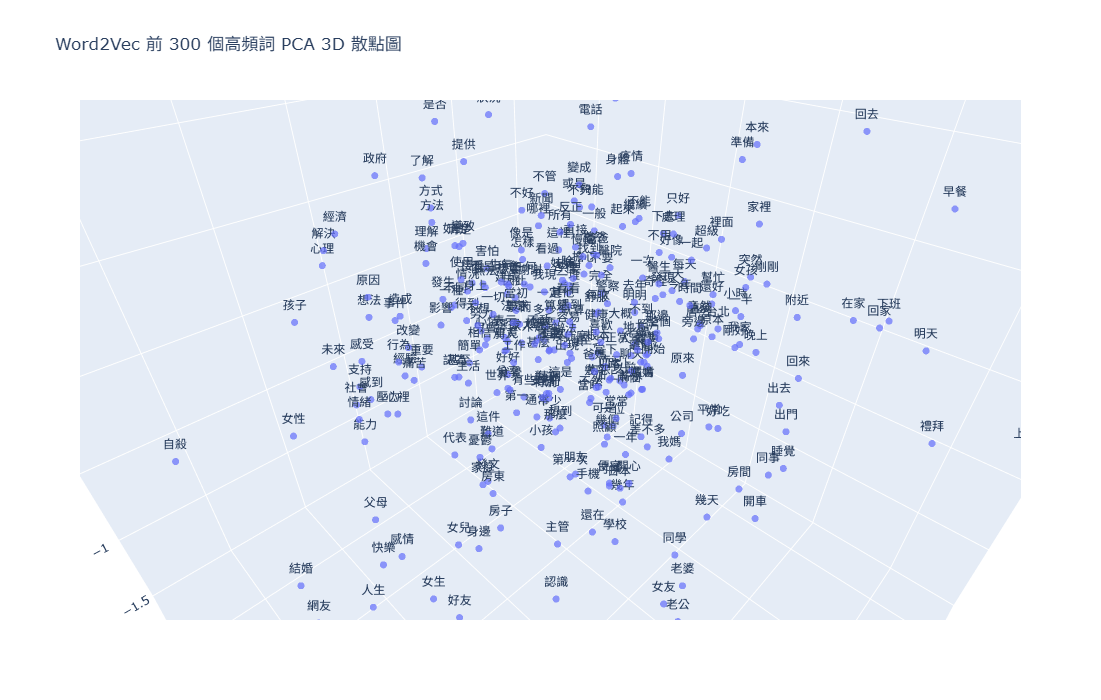

In [142]:
import plotly.express as px

fig = px.scatter_3d(
    word_df,
    x="dim1",
    y="dim2",
    z="dim3",
    text="word",
    hover_name="word",
    hover_data=["count"],
    opacity=0.7,
    width=900,
    height=700,
    title="Word2Vec 前 300 個高頻詞 PCA 3D 散點圖"
)

fig.update_traces(
    marker=dict(size=4),
    textposition="top center"
)

fig.show(config={
    "displayModeBar": True,
    "scrollZoom": True,
    "displaylogo": False
})


## 分群




In [147]:
from sklearn.cluster import KMeans

def cluster(X, n=3):
    model = KMeans(n_clusters=n, random_state=0)
    model.fit(X)
    result = model.predict(X)
    return result

In [149]:
colors = cluster(feat, n=3)

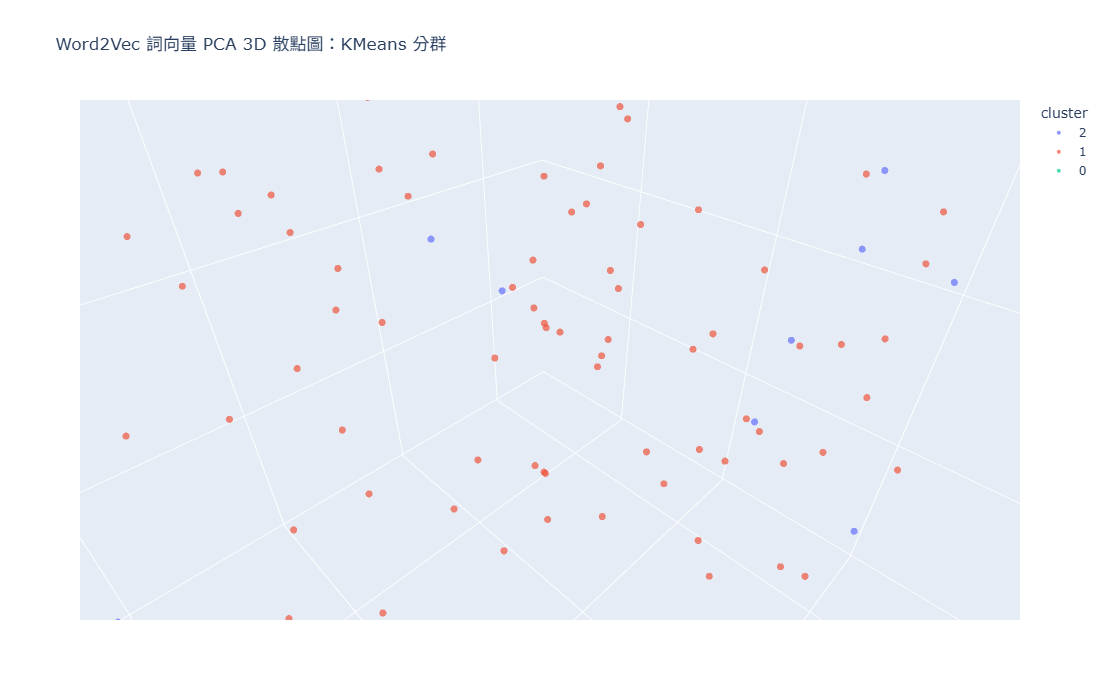

In [151]:
from sklearn.cluster import KMeans
import plotly.express as px

# 分群函式
def cluster(X, n=3):
    model = KMeans(n_clusters=n, random_state=0)
    model.fit(X)
    return model.predict(X)

# 對詞向量分成 3 群
word_df["cluster"] = cluster(feat, n=3).astype(str)

# 畫 3D 分群圖
fig = px.scatter_3d(
    word_df,
    x="dim1",
    y="dim2",
    z="dim3",
    color="cluster",
    hover_name="word",
    hover_data=["count"],
    opacity=0.7,
    width=900,
    height=700,
    title="Word2Vec 詞向量 PCA 3D 散點圖：KMeans 分群"
)

fig.update_traces(
    marker=dict(size=4)
)

fig.show(config={
    "displayModeBar": True,
    "scrollZoom": True,
    "displaylogo": False
})

In [153]:
top_n = 300
sample_words = w2v_model.wv.index_to_key[:top_n]
feat = np.array([w2v_model.wv[word] for word in sample_words])

In [161]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.express as px

# 取前 300 個高頻詞
top_n = 300
sample_words = w2v_model.wv.index_to_key[:top_n]

# 取得詞向量
feat = np.array([w2v_model.wv[word] for word in sample_words])

# PCA 降成 3 維
pca = PCA(n_components=3, random_state=42)
new_feat = pca.fit_transform(feat)

# 建立 DataFrame
word_df = pd.DataFrame({
    "word": sample_words,
    "dim1": new_feat[:, 0],
    "dim2": new_feat[:, 1],
    "dim3": new_feat[:, 2],
    "count": [w2v_model.wv.get_vecattr(word, "count") for word in sample_words]
})

# KMeans 分群
kmeans = KMeans(n_clusters=3, random_state=0)
word_df["cluster"] = kmeans.fit_predict(feat).astype(str)

# 畫 3D 圖
word_df["label"] = ""
word_df.loc[word_df.index[:50], "label"] = word_df["word"].iloc[:50]

fig = px.scatter_3d(
    word_df,
    x="dim1",
    y="dim2",
    z="dim3",
    color="cluster",
    text="label",         # 只顯示 label 欄位
    hover_name="word",    # 滑鼠移過去仍會顯示完整詞
    hover_data=["count"],
    opacity=0.7,
    width=900,
    height=700,
    title="Word2Vec 前 300 個高頻詞 PCA 3D 散點圖：KMeans 分群 顯示前 50 個詞的文字，其他點用滑鼠 hover 才顯示"
)

fig.update_traces(
    marker=dict(size=4),
    textposition="top center"
)

fig.show(config={
    "displayModeBar": True,
    "scrollZoom": True,
    "displaylogo": False
})


#  使用Sentence embedding做NLP任務




In [ ]:
#相似文件

In [3]:
import sys
!{sys.executable} -m pip install sentence-transformers

In [5]:
from sentence_transformers import SentenceTransformer

print("sentence-transformers 載入成功")

sentence-transformers 載入成功


In [7]:
bert_ch = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [18]:
import re
import pandas as pd
from sentence_transformers import SentenceTransformer

# 1. 重新建立 df_similar
df_similar = df[["system_id", "artTitle", "artContent"]].copy()

df_similar["artContent"] = df_similar["artContent"].fillna("").astype(str)

# 2. 清理文章內容，只保留中文
df_similar["clean_content"] = df_similar["artContent"].apply(
    lambda x: re.sub(r"[^\u4e00-\u9fff]+", "", x)
)

# 3. BERT 文字長度不要太長，先取前 500 個中文字
df_similar["bert_text"] = df_similar["clean_content"].str[:500]

df_similar.head()

NameError: name 'df' is not defined

In [178]:
bert_ch = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [180]:
texts = df_similar["bert_text"].head(100).tolist()

embeddings = bert_ch.encode(
    texts,
    batch_size=16,
    show_progress_bar=True
)

print("embedding shape:", embeddings.shape)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

embedding shape: (100, 384)


In [182]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query = "朋友突然疏遠我，讓我覺得很傷心和孤單"

query_embedding = bert_ch.encode([query])

similarity_scores = cosine_similarity(
    query_embedding,
    embeddings
).flatten()

top_indices = similarity_scores.argsort()[::-1][:10]

query_results = df_similar.head(100).iloc[top_indices].copy()
query_results["similarity"] = similarity_scores[top_indices]

query_results[["system_id", "artTitle", "similarity"]]

,system_id,artTitle,similarity
2,3,[閒聊]關於朋友這件事：（,0.683387
10,11,[難過]一直遺憾當初沒有救回自殺的朋友.很想他,0.582767
26,27,[閒聊]想到難過事會落淚是還沒放下嗎,0.558188
72,73,[心情]有人也是個性轉變很大的人嗎?,0.544337
28,29,[閒聊]很怕遇到超商門口或提款機前拿碗要錢的人,0.535102
94,95,結婚禮金到底要包多少,0.523806
71,72,[閒聊]被說是很兇的人,0.510228
13,14,Re:[難過]一直遺憾當初沒有救回自殺的朋友.很想他,0.509801
62,63,[閒聊]覺得難過，連苦都不能訴,0.506497
66,67,[難過]兄弟倆為何不能好好相處呢?,0.494540


In [184]:
texts = df_similar["bert_text"].tolist()

embeddings_all = bert_ch.encode(
    texts,
    batch_size=16,
    show_progress_bar=True
)

print("embedding shape:", embeddings_all.shape)

Batches:   0%|          | 0/473 [00:00<?, ?it/s]

embedding shape: (7564, 384)


In [188]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query = "朋友突然疏遠我，讓我覺得很傷心和孤單"

query_embedding = bert_ch.encode([query])

similarity_scores = cosine_similarity(
    query_embedding,
    embeddings_all
).flatten()

top_indices = similarity_scores.argsort()[::-1][:10]

query_results = df_similar.iloc[top_indices].copy()
query_results["similarity"] = similarity_scores[top_indices]

query_results[["system_id", "artTitle", "similarity"]]

,system_id,artTitle,similarity
5185,5188,[心情]沒有朋友突然覺得很孤獨,0.791249
3269,3272,[難過]我好崩潰,0.773683
1061,1063,[難過]困擾好久的事,0.751372
1189,1191,[問題]所謂像家人般的存在,0.738182
369,370,[難過]當我找回情感後比以前更加寂寞,0.736620
5180,5183,[心情]很久的好朋友離我遠去,0.716041
511,513,[難過]一個人住會覺得很寂寞嗎？,0.707965
5744,5751,[難過]討厭的人一直出現,0.701484
1570,1572,Re:[難過]跟好朋友鬧翻了,0.692630
5977,5984,[難過]現實中完全沒有朋友,0.690620


In [188]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query = "朋友突然疏遠我，讓我覺得很傷心和孤單"

query_embedding = bert_ch.encode([query])

similarity_scores = cosine_similarity(
    query_embedding,
    embeddings_all
).flatten()

top_indices = similarity_scores.argsort()[::-1][:10]

query_results = df_similar.iloc[top_indices].copy()
query_results["similarity"] = similarity_scores[top_indices]

query_results[["system_id", "artTitle", "similarity"]]

,system_id,artTitle,similarity
5185,5188,[心情]沒有朋友突然覺得很孤獨,0.791249
3269,3272,[難過]我好崩潰,0.773683
1061,1063,[難過]困擾好久的事,0.751372
1189,1191,[問題]所謂像家人般的存在,0.738182
369,370,[難過]當我找回情感後比以前更加寂寞,0.736620
5180,5183,[心情]很久的好朋友離我遠去,0.716041
511,513,[難過]一個人住會覺得很寂寞嗎？,0.707965
5744,5751,[難過]討厭的人一直出現,0.701484
1570,1572,Re:[難過]跟好朋友鬧翻了,0.692630
5977,5984,[難過]現實中完全沒有朋友,0.690620


In [ ]:
##取得整個文集的 embeddings

In [192]:
from sentence_transformers import util
import torch

# =====================================================
# 1. 取得整個文集的 embeddings
# =====================================================

corpus_embeddings = bert_ch.encode(
    df_similar["artContent"].fillna("").astype(str).tolist(),
    convert_to_tensor=True,
    batch_size=32,
    show_progress_bar=True
)

print("corpus_embeddings shape:", corpus_embeddings.shape)

Batches:   0%|          | 0/237 [00:00<?, ?it/s]

corpus_embeddings shape: torch.Size([7564, 384])


In [196]:
# =====================================================
# 2. 指定要查詢的文章
# =====================================================

query_num = 10   # 指定第幾篇文章
top_k = 5       # 找最相似的前 5 篇


# =====================================================
# 3. 把指定文章轉成 embedding
# =====================================================

query_text = str(df_similar["artContent"].iloc[query_num])

query_embedding = bert_ch.encode(
    query_text,
    convert_to_tensor=True
)


# =====================================================
# 4. 計算 cosine similarity
# =====================================================

cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]


# =====================================================
# 5. 取出最高分的前 top_k + 1 篇
# 因為最像的一定會包含自己，所以後面會排除自己
# =====================================================

top_results = torch.topk(cos_scores, k=top_k + 1)


# =====================================================
# 6. 顯示結果
# =====================================================

print("\n====================")
print("Query:", df_similar["artTitle"].iloc[query_num])
print("\n資料集中前五相似的文章：")

count = 0

for score, idx in zip(top_results.values, top_results.indices):
    idx = int(idx)

    # 排除自己
    if idx == query_num:
        continue

    print(
        df_similar["artTitle"].iloc[idx],
        "(Score: {:.4f})".format(float(score))
    )

    count += 1
    if count >= top_k:
        break

print("====================\n")


Query: [難過]一直遺憾當初沒有救回自殺的朋友.很想他

資料集中前五相似的文章：
[心情]最近的人生一團糟 (Score: 0.8102)
[難過]能回到過去會想要改變甚麼？ (Score: 0.8015)
[討論]親友想輕生會怎麼做？ (Score: 0.7964)
Re:[難過]近視雷射手術後…(文長) (Score: 0.7875)
[難過]久病厭世但卻不得不繼續存在 (Score: 0.7771)



## ---
#  使用embedding做分類任務





In [121]:
from pathlib import Path

print("目前工作目錄：", Path.cwd())

for f in Path.cwd().iterdir():
    print(f.name)

目前工作目錄： C:\Users\uh52j\Untitled Folder
.ipynb_checkpoints
1150428 - Copy.ipynb
1150505.ipynb
RawdataLabled.csv
results
study_group3 - Part 1.ipynb
study_group3.ipynb


In [123]:
import pandas as pd
from pathlib import Path

file_path = Path(r"C:\Users\uh52j\OneDrive\桌面\社群讀書會\RawdataLabled.csv")

df_labeled = pd.read_csv(file_path, encoding="utf-8-sig")

df_labeled.head()

,system_id,artUrl,artTitle,artDate,artContent,bert_text,label
0,1,https://www.ptt.cc/bbs/WomenTalk/M.1609431742....,[難過]2020年12月步數不足,2021/1/1 00:22,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,[難過]2020年12月步數不足2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都...,NaN
1,2,https://www.ptt.cc/bbs/WomenTalk/M.1609453123....,[難過]陽台又淹水了,2021/1/1 06:18,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,[難過]陽台又淹水了大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門...,NaN
2,3,https://www.ptt.cc/bbs/WomenTalk/M.1609473812....,[閒聊]關於朋友這件事：（,2021/1/1 12:03,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,[閒聊]關於朋友這件事：（不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是...,friend_related
3,4,https://www.ptt.cc/bbs/WomenTalk/M.1609520172....,[討論]大家都怎麼形容自己非常難過,2021/1/2 00:56,小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來說去\n\n就一直只能\n“說我真...,[討論]大家都怎麼形容自己非常難過小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來...,NaN
4,5,https://www.ptt.cc/bbs/WomenTalk/M.1609527385....,Re:[討論]大家都怎麼形容自己非常難過,2021/1/2 02:56,難過是什麼？\n為什麼要形容難過？\n形容難過形容的很好可以幹嘛？\n世界就會變好了嗎？\n...,Re:[討論]大家都怎麼形容自己非常難過難過是什麼？\n為什麼要形容難過？\n形容難過形容的...,NaN


In [125]:
import pandas as pd
from pathlib import Path

file_path = Path(r"C:\Users\uh52j\OneDrive\桌面\社群讀書會\RawdataLabled.csv")

df_labeled = pd.read_csv(
    file_path,
    encoding="utf-8-sig",
    sep=None,
    engine="python"
)

print(df_labeled.shape)
print(df_labeled.columns.tolist()[:20])
df_labeled.head()

(7616, 7)
['system_id', 'artUrl', 'artTitle', 'artDate', 'artContent', 'bert_text', 'label']


,system_id,artUrl,artTitle,artDate,artContent,bert_text,label
0,1,https://www.ptt.cc/bbs/WomenTalk/M.1609431742....,[難過]2020年12月步數不足,2021/1/1 00:22,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,[難過]2020年12月步數不足2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都...,NaN
1,2,https://www.ptt.cc/bbs/WomenTalk/M.1609453123....,[難過]陽台又淹水了,2021/1/1 06:18,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,[難過]陽台又淹水了大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門...,NaN
2,3,https://www.ptt.cc/bbs/WomenTalk/M.1609473812....,[閒聊]關於朋友這件事：（,2021/1/1 12:03,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,[閒聊]關於朋友這件事：（不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是...,friend_related
3,4,https://www.ptt.cc/bbs/WomenTalk/M.1609520172....,[討論]大家都怎麼形容自己非常難過,2021/1/2 00:56,小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來說去\n\n就一直只能\n“說我真...,[討論]大家都怎麼形容自己非常難過小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來...,NaN
4,5,https://www.ptt.cc/bbs/WomenTalk/M.1609527385....,Re:[討論]大家都怎麼形容自己非常難過,2021/1/2 02:56,難過是什麼？\n為什麼要形容難過？\n形容難過形容的很好可以幹嘛？\n世界就會變好了嗎？\n...,Re:[討論]大家都怎麼形容自己非常難過難過是什麼？\n為什麼要形容難過？\n形容難過形容的...,NaN


In [43]:
print(df_labeled.shape)

(7616, 7)


In [127]:
import pandas as pd
from pathlib import Path

file_path = Path(r"C:\Users\uh52j\OneDrive\桌面\社群讀書會\RawdataLabled.csv")

df_labeled = pd.read_csv(
    file_path,
    encoding="utf-8-sig",
    sep=None,
    engine="python"
)

print(df_labeled.shape)
print(df_labeled.columns.tolist()[:20])
df_labeled.head()

(7616, 7)
['system_id', 'artUrl', 'artTitle', 'artDate', 'artContent', 'bert_text', 'label']


,system_id,artUrl,artTitle,artDate,artContent,bert_text,label
0,1,https://www.ptt.cc/bbs/WomenTalk/M.1609431742....,[難過]2020年12月步數不足,2021/1/1 00:22,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n...,[難過]2020年12月步數不足2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都...,NaN
1,2,https://www.ptt.cc/bbs/WomenTalk/M.1609453123....,[難過]陽台又淹水了,2021/1/1 06:18,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰...,[難過]陽台又淹水了大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門...,NaN
2,3,https://www.ptt.cc/bbs/WomenTalk/M.1609473812....,[閒聊]關於朋友這件事：（,2021/1/1 12:03,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過...,[閒聊]關於朋友這件事：（不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是...,friend_related
3,4,https://www.ptt.cc/bbs/WomenTalk/M.1609520172....,[討論]大家都怎麼形容自己非常難過,2021/1/2 00:56,小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來說去\n\n就一直只能\n“說我真...,[討論]大家都怎麼形容自己非常難過小弟才疏學淺\n\n最近想表達自己狀況不好\n\n但是我來...,NaN
4,5,https://www.ptt.cc/bbs/WomenTalk/M.1609527385....,Re:[討論]大家都怎麼形容自己非常難過,2021/1/2 02:56,難過是什麼？\n為什麼要形容難過？\n形容難過形容的很好可以幹嘛？\n世界就會變好了嗎？\n...,Re:[討論]大家都怎麼形容自己非常難過難過是什麼？\n為什麼要形容難過？\n形容難過形容的...,NaN


In [47]:
# 檢查 label 分布，包含空值
df_labeled["label"].value_counts(dropna=False)

label
NaN               7547
friend_related      23
pet_related         21
family_related      18
other                7
Name: count, dtype: int64

In [131]:
df_train = df_labeled.copy()

df_train["label"] = df_train["label"].fillna("").astype(str).str.strip()
df_train["bert_text"] = df_train["bert_text"].fillna("").astype(str).str.strip()

df_train = df_train[
    (df_train["label"] != "") &
    (df_train["bert_text"] != "")
].copy()

print(df_train.shape)
print(df_train["label"].value_counts())

(69, 7)
label
friend_related    23
pet_related       21
family_related    18
other              7
Name: count, dtype: int64


In [133]:
from sentence_transformers import SentenceTransformer

bert_ch = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

texts = df_train["bert_text"].tolist()

X = bert_ch.encode(
    texts,
    batch_size=16,
    show_progress_bar=True
)

y = df_train["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

X shape: (69, 384)
y shape: (69,)
label
friend_related    23
pet_related       21
family_related    18
other              7
Name: count, dtype: int64


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

family_related       0.80      1.00      0.89         4
friend_related       1.00      0.80      0.89         5
         other       0.00      0.00      0.00         1
   pet_related       1.00      1.00      1.00         4

      accuracy                           0.86        14
     macro avg       0.70      0.70      0.69        14
  weighted avg       0.87      0.86      0.86        14



<Figure size 800x600 with 0 Axes>

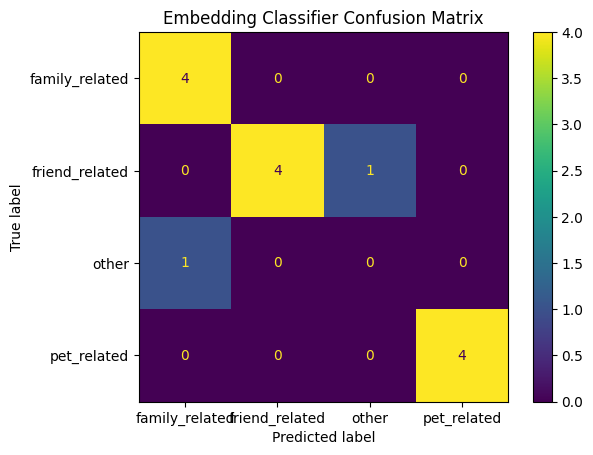

In [55]:
labels = clf.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

plt.figure(figsize=(8, 6))
disp.plot(values_format="d")
plt.title("Embedding Classifier Confusion Matrix")
plt.show()

In [57]:
df_labeled["label"].value_counts(dropna=False)

label
NaN               7547
friend_related      23
pet_related         21
family_related      18
other                7
Name: count, dtype: int64

In [59]:
texts_all = df_labeled["bert_text"].fillna("").astype(str).tolist()

X_all = bert_ch.encode(
    texts_all,
    batch_size=16,
    show_progress_bar=True
)

df_labeled["pred_label"] = clf.predict(X_all)

pred_probs = clf.predict_proba(X_all)
df_labeled["pred_confidence"] = pred_probs.max(axis=1)

df_labeled[["system_id", "artTitle", "pred_label", "pred_confidence"]].head()

Batches:   0%|          | 0/476 [00:00<?, ?it/s]

,system_id,artTitle,pred_label,pred_confidence
0,1,[難過]2020年12月步數不足,family_related,0.414147
1,2,[難過]陽台又淹水了,family_related,0.580474
2,3,[閒聊]關於朋友這件事：（,friend_related,0.952272
3,4,[討論]大家都怎麼形容自己非常難過,friend_related,0.378532
4,5,Re:[討論]大家都怎麼形容自己非常難過,friend_related,0.458595


In [61]:
target_labels = ["friend_related", "family_related"]

related_ratio = df_labeled["pred_label"].isin(target_labels).mean()

print(f"模型預測朋友或家人相關比例：{related_ratio:.2%}")

模型預測朋友或家人相關比例：66.57%


In [ ]:
#5-fold cross validation

In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

clf_cv = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

scores = cross_val_score(
    clf_cv,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("5-fold accuracy:", scores)
print("平均 accuracy:", round(scores.mean(), 4))
print("標準差:", round(scores.std(), 4))

5-fold accuracy: [0.78571429 0.92857143 1.         0.92857143 0.84615385]
平均 accuracy: 0.8978
標準差: 0.0743


In [65]:
f1_scores = cross_val_score(
    clf_cv,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("5-fold macro F1:", f1_scores)
print("平均 macro F1:", round(f1_scores.mean(), 4))
print("標準差:", round(f1_scores.std(), 4))

5-fold macro F1: [0.60972222 0.88888889 1.         0.9        0.80555556]
平均 macro F1: 0.8408
標準差: 0.131
